# Поведенческий скоринг для предсказания дефолта по кредиту

Проект производит поведенческий скоринг пользователей банка, определяя вероятность дефолта, то есть задержки платежей по кредиту сверх 90 дней.

## Содержание
1. <a href="#problem_statement">✅ Постановка задачи</a>
1. <a href="#environment">✅ Подготовка окружения</a>
1. <a href="#explore_data">✅ Исследовательский анализ данных</a>
1. <a href="#dataset">✅ Формирование датасета</a>
1. <a href="#modelling">✅ Моделирование</a>
1. <a href="#calibration">✅ Калибровка модели</a>
1. <a href="#find_threshold">✅ Поиск порога решения</a>
1. <a href="#conf_matrix">✅ Анализ матрицы ошибок</a>
1. <a href="#final_model">✅ Фиксирование итоговой модели</a>
1. <a href="#feature_importance">✅ Анализ важности признаков</a>
1. <a href="#final_report">✅ Выводы по проекту</a>











<a id="problem_statement"></a>

## Постановка задачи машинного обучения


### Бизнес-контекст

Банк хочет заранее понимать, какие действующие клиенты могут уйти в серьезную просрочку по кредиту. Обычный кредитный скоринг помогает только на этапе выдачи кредита, а здесь задача другая - следить за уже существующим портфелем и вовремя замечать рост риска.

Если модель будет хорошо находить таких клиентов заранее, банк сможет лучше управлять резервами, снизить риски и не замораживать лишние деньги.

### Цель исследования

Нужно построить модель, которая по данным о клиенте в конкретный месяц будет предсказывать, случится ли у него в ближайшие 12 месяцев просрочка 90+ дней.

### Постановка задачи машинного обучения

Это задача бинарной классификации:

- 1 - если в следующие 12 месяцев у клиента появится просрочка 90+ дней;
- 0 - если нет.

Каждая строка - это клиент в определенный месяц, поэтому здесь важно учитывать временную структуру данных и аккуратно собирать признаки, чтобы не было утечки данных из будущего.

В данные входят разные группы признаков:

- информация о клиенте;
- параметры кредита;
- траты по MCC-категориям;
- кредитный рейтинг;
- наличие ипотеки;
- макроэкономические показатели;
- новые агрегированные признаки, которые будут созданы в ходе проекта.

Сначала все таблицы нужно объединить в одну итоговую выборку, потом подготовить признаки и целевую переменную.

### Какие модели будем сравнивать

Планируется сравнить логистическую регрессию как базовую модель и Random Forest как основную модель для итогового решения.

Модели будут обучаться:
- на исходных данных;
- на данных с балансировкой классов.

Для итогового решения будет использоваться Random Forest с подбором гиперпараметров через Optuna.

Так как данные временные, для кросс-валидации нужно использовать GroupTimeSeriesSplit, чтобы не перемешивать прошлое и будущее.

### Метрики

Главные метрики здесь бизнесовые:

- Approval rate - доля клиентов, которых модель считает надежными;
- Default rate - доля дефолтов среди тех, кого модель посчитала надежными;
- Missed defaults rate - доля дефолтов, которые модель пропустила.

Дополнительно можно смотреть ROC-AUC или accuracy, precision, recall, f1 для общего сравнения моделей.

### Что нужно получить в итоге

Нужно подобрать такую модель и такой порог вероятности, чтобы выполнялись условия:

- Approval rate не меньше 65%;
- Default rate не больше 2%;
- Missed defaults rate не больше 4%.

После этого модель нужно проверить на тестовой выборке и посмотреть, насколько стабильно она работает.

<a id="environment"></a>

## Подготовка окружения и загрузка данных

### Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [1]:
! rm requirements.txt

In [2]:
from pathlib import Path

requirements_file = Path('requirements.txt')
requirements = [
    'phik==0.12.5',
    'joblib==1.5.3',
    'scikit-learn==1.6.1',
    'seaborn==0.13.2',
    'optuna==4.8.0',
    'plotly==6.7.0',
    'humanfriendly==10.0',
    'mlxtend==0.23.4',
    'imbalanced-learn==0.14.1',
]
if not requirements_file.exists():
    with open(requirements_file, 'w') as f:
        f.write('\n'.join(requirements))
        print(f'{requirements_file} created')
else:
    print(f'{requirements_file} exists')

print('Установка зависимостей...')
!pip install -r requirements.txt
print('Зависимости успешно установлены!')


requirements.txt created
Установка зависимостей...

[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Зависимости успешно установлены!


In [3]:
import os
import requests
from datetime import datetime
import optuna
import time
import joblib
from phik import phik_matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate, cross_val_score, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    make_scorer,
    brier_score_loss,
    confusion_matrix,
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve, CalibrationDisplay
from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
)

from humanfriendly import format_size


/Users/ngsmirnov/nikki/projects/practicum/sprint15_randforest_credit_default_classif/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Подготовка параметров тетрадки и утилит:

In [4]:
TARGET_COL_NAME = 'target'
RANDOM_STATE = 153
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None) # выводить все колонки
pd.set_option('display.max_colwidth', 500) # выводить больше символов в ячейке

#### Заргузка ресурсов
class ResourceLoader:
    """
    Класс для безопасной загрузки ресурсов по http: датасет и произвольный файл.
    Если файл уже был скачан ранее и сохранен в локальной файловой системе, то
    загрузка из удаленного источника не производится.

    Для загрузки датасета: load_dataset(dataset_url, local_file, local_path='datasets'): dataframe
    Для загрузки файла: load_resource(resource_url, local_path, local_file): path
    """

    def __init__(self):
        pass

    def load_resource(self, resource_url, local_path, local_file):
        local_resource_file = f'{local_path}/{local_file}'
        if os.path.exists(local_resource_file):
            print(f'Файл {local_resource_file} уже существует')
            return local_resource_file

        os.makedirs(local_path, exist_ok=True)
        print(f'Загружаем файл из {resource_url}')
        response = requests.get(resource_url)
        if response.status_code == 200:
            with open(local_resource_file, 'wb') as f:
                f.write(response.content)
            file_size = format_size(os.path.getsize(local_resource_file))
            print(f'Файл успешно загружен в {local_resource_file},',
                  f'размер файла: {file_size}')
            return local_resource_file
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')


    def load_dataset(
        self,
        dataset_url,
        local_file = None,
        local_path='datasets',
        sep=',',
        decimal='.'
    ):
        if local_file is None:
            local_file = dataset_url.split('/')[-1]
        local_dataset_file = f'{local_path}/{local_file}'
        remote_dataset_url = dataset_url
        def read_dataset_csv():
            return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

        try:
            df = read_dataset_csv()
            print(f'Датасет успешно загружен из {local_dataset_file}')
        except FileNotFoundError:
            self.load_resource(remote_dataset_url, local_path, local_file)
            df = read_dataset_csv()

        print(f'Размер загруженного датасета: {df.shape[0]} строк, {df.shape[1]} столбцов', )
        return df

#### EDA
class CorrelationDisplayer:
    """
    Класс для отображения матрицы корреляций признаков в разных видах
    """
    def __init__(self, corr_matrix):
        self.corr_matrix = corr_matrix

    def get_corr_matrix(self):
        return self.corr_matrix

    def _subset_corr_matrix(self, subset):
        subset_cols = self.corr_matrix.columns if subset is None else subset
        return self.corr_matrix.loc[subset_cols, subset_cols]

    def draw_corr_matrix_full(
            self,
            digits=2,
            title='Матрица корреляций признаков',
            subtitle=None,
            figsize=(16, 10),
            subset=None,
    ):
        plt.subplots(figsize=figsize)
        matrix = self._subset_corr_matrix(subset)
        sns.heatmap(matrix.round(digits), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()


    def draw_corr_matrix_with_target(
            self,
            target_col,
            title='Матрица корреляций с таргетом',
            subtitle=None,
            figsize=(16, 10),
    ):
        plt.subplots(figsize=figsize)
        data_heatmap = self.corr_matrix.loc[
            self.corr_matrix.index != target_col
        ][[target_col]].sort_values(by=target_col, ascending=False)
        sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()

    def draw_pair_correlations(self, subset=None, figsize=(16, 10), corr_threshold=0.9):
        # преобразуем матрицу корреляции в датафрейм попарных корреляций
        # feature_1+feature_2 -> correlation
        matrix = self._subset_corr_matrix(subset)
        pair_correlations = matrix \
            .stack() \
            .reset_index() \
            .rename(columns={
                'level_0': 'feature1',
                'level_1': 'feature2',
                0: 'correlation'
            }) \
            .query('feature1 != feature2') \
            .sort_values(by='correlation', ascending=False) \

        def order_pair(row):
            if row['feature1'] > row['feature2']:
                return row['feature2'] + '/' + row['feature1']
            else:
                return row['feature1'] + '/' + row['feature2']

        pair_correlations['order_pair'] = pair_correlations.apply(order_pair, axis=1)
        pair_correlations = pair_correlations.drop(columns=['feature1', 'feature2'])
        pair_correlations = pair_correlations.drop_duplicates().reset_index(drop=True)
        pair_correlations = pair_correlations.query('correlation > @corr_threshold')
        pair_correlations = pair_correlations.sort_values(by='correlation')
        pair_correlations.plot(
            x='order_pair',
            y='correlation',
            xlabel='Значение корреляции',
            ylabel='Пара признаков',
            kind='barh',
            legend=False,
            figsize=figsize,
            grid=True,
        )
        plt.title('Попарные корреляции')
        plt.show()
        return pair_correlations.sort_values(by='correlation', ascending=False).reset_index(drop=True)

class EDAHelper:
    def __init__(self):
        pass

    def df_info(self, df, name = '', n_samples=3):
        print('-'*50)
        print(f'Описание датасета {name}:')
        print(f'Датасет {name} содержит {df.shape[0]} строк и {df.shape[1]} столбцов.')
        print(f'Размер датасета {name} в памяти: {format_size(df.memory_usage().sum())}')
        print('-'*50)

        print(df.info())
        print('-'*50)
        print(f'Данные датасета {name}:')
        print('-'*50)
        display(
            pd.concat([
                df.head(n_samples).assign(place='head'),
                df.sample(n_samples, random_state=RANDOM_STATE).assign(place='random'),
                df.tail(n_samples).assign(place='tail'),
            ]).sort_index()
        )
        nan_counts = self.na_info(df)
        if (len(nan_counts) > 0):
            display(nan_counts)
        else:
            print(f'В датасете {name} нет пропущенных значений')

    def convert_to_datetime(self, df, column, format='%Y-%m-%d', print_time_range=True):
        df[column] = pd.to_datetime(df[column], format=format)
        if print_time_range:
            self.print_time_range(df, column)
        return df


    def print_time_range(self, df, datetime_column):
        # определим временную ось таблицы:
        start_date = df[datetime_column].min()
        end_date = df[datetime_column].max()
        diff = int((end_date - start_date) / np.timedelta64(1, 'D'))
        diff_years = diff / 365.25

        print(f'Данные в "{datetime_column}" представлены за период {diff} дн. ({diff_years:.1f} л.): {start_date} - {end_date}')

    def box_hist(self, df, column, title=None, bins=20, hue=None, kde=True, stat='density'):
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
        print(df[[column]].describe())
        sns.boxplot(df[column], orient='h', ax=ax_box)
        sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=kde, stat=stat)

        f.suptitle(f'Распределение признака {column}' if title is None else title)
        ax_box.set(xlabel='')
        ax_hist.set(
            xlabel=f'Значения признака {column}',
            ylabel='Плотность распределения'
        )
        plt.show()

    def time_line(self, df, datetime_column, y_column, ylabel=None):
        if ylabel is None:
            ylabel = y_column

        df.plot(
            kind='line',
            x=datetime_column,
            y=y_column,
            xlabel='Дата',
            ylabel=ylabel,
            title=f'Завимость признака "{y_column}" от времени',
            legend=False,
        )
        plt.show()

    def drop_duplicates(self, df, subset=None):
        ndups = df.duplicated(subset=subset).sum()
        print(f'Найдено {ndups} дубликатов по {"всем" if subset is None else subset} столбцам')
        if ndups > 0:
            df_orig = df.copy()
            df.drop_duplicates(subset=subset, inplace=True)
            diff = len(df_orig) - len(df)
            diff_pct = diff / len(df_orig) * 100
            print(f'Удалено {diff} строк ({diff_pct:.1f}%) из {len(df_orig)}')
        else:
            print('Дубликатов не обнаружено')

    def na_info(self, df, round_digits=1):
        '''
        Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
        '''
        count_na_name = 'Количество пропусков'
        res = pd.DataFrame({
            'Количество строк': len(df),
            count_na_name: df.isna().sum(),
            'Процент пропусков': round(df.isna().mean()*100, round_digits)
        }).sort_values(by=count_na_name, ascending=False)
        return res.query(f'`{count_na_name}` > 0').reset_index()


    # Уникальные значения всех категориальных признаков
    def print_unique_values(self, df, top_n=5):
        print('Уникальные значения всех категориальных признаков:\n')
        for col in df.select_dtypes(include=['object']).columns:
            unique_vals = df[col].unique().tolist()
            unique_vals.sort()
            top_n_vals = ', '.join(unique_vals[:top_n])
            unique_val_str =  top_n_vals if len(unique_vals) <= top_n else f'{top_n_vals}, ...'
            print(f'{col} [{df[col].nunique()}]: {unique_val_str}')

### Обучение модели
class ModelTrainHelper:
    def __init__(self):
        self.best_estimator_ = None
        pass

    def do_cross_validation(
            self,
            pipelines,
            X_train_val, y_train_val,
            scoring,
            metrics_df_list = [],
            return_train_score=False,
            cv=5,
            digits=3,
    ):

        cv_results_by_model = {}
        # Обучение моделей
        for name, p in pipelines.items():
            cv_results = cross_validate(
                estimator=p,
                X=X_train_val,
                y=y_train_val,
                scoring=scoring,
                return_train_score=return_train_score,
                return_estimator=True,
                cv=cv,
                verbose=0,
                n_jobs=-1,
            )
            cv_results_by_model[name] = cv_results

        def non_negative_metric(metric):
            if metric.startswith('neg_'):
                return (True, metric[len('_neg'):])
            else:
                return (False, metric)

        is_neg_main_metric, main_metric = non_negative_metric(scoring[0])

        # Сохранение результатов в сводную таблицу:
        def append_metrics(result_metrics, model_name, cv_results, test_or_train='test', scoring=[]):
            metrics_dict = {}

            metrics_dict['model_name'] = model_name
            metrics_dict = metrics_dict | {
                metric: np.mean(cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            }
            # for metric in scoring:
            #     print(metric, cv_results[f'{test_or_train}_{metric}'])
            # add standard deviation
            # metrics_dict = metrics_dict | {
            #     f'{metric}_std': np.std(-cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            # }

            keys = list(metrics_dict.keys())
            for metric in keys:
                # invert sign for neg metrics like neg_mean_squared_error
                # and rename metrics withoud neg
                if metric.startswith('neg_'):
                    metrics_dict[metric[len('neg_'):]] = metrics_dict[metric] * -1 if not metric.endswith('_std') else 1
                    metrics_dict.pop(metric)

            result_metrics.append(metrics_dict)
            return metrics_dict

        for model_name, model_cv_results in cv_results_by_model.items():
            append_metrics(
                metrics_df_list,
                model_name,
                model_cv_results,
                scoring=scoring,
            )
            if return_train_score and 'dummy' not in model_name.lower():
                append_metrics(
                    metrics_df_list,
                    f'{model_name} (train)',
                    model_cv_results,
                    test_or_train='train',
                    scoring=scoring,
                )

        metrics_df = pd.DataFrame(metrics_df_list) \
            .sort_values(by=main_metric, ascending=is_neg_main_metric)

        metrics_df.set_index('model_name', inplace=True)
        return metrics_df.sort_index(axis=1)

    def confusion_matrix_displayed(self, y_true, y_pred, true_desc='Уйдет', false_desc='Останется'):
        cm = confusion_matrix(y_true, y_pred)

        # Визуализируем матрицу
        plt.figure(figsize=(8, 6))

        # Отображаем матрицу как изображение
        im = plt.imshow(cm, interpolation='nearest', cmap='Blues')
        plt.colorbar(im)

        # Добавляем подписи осей
        plt.xlabel('Предсказанные классы', fontsize=12)
        plt.ylabel('Истинные классы', fontsize=12)
        plt.title('Матрица ошибок', fontsize=14)

        # Настраиваем метки на осях
        tick_marks = [0, 1]
        plt.xticks(tick_marks, [false_desc, true_desc])
        plt.yticks(tick_marks, [false_desc, true_desc])

        # Матрица имеет структуру:
        matrix_desc = [
            ['TN', 'FP'],
            ['FN', 'TP'],
        ]

        # Добавляем числовые значения в ячейки
        for i in range(2):
            for j in range(2):
                plt.text(j, i, f'{matrix_desc[i][j]} {cm[i, j]}',
                        ha='center', va='center',
                        color='white' if cm[i, j] > cm.max()/2 else 'black',
                        fontsize=14)

        plt.tight_layout()
        plt.show()


        tn = cm[0, 0]
        fp = cm[0, 1]
        fn = cm[1, 0]
        tp = cm[1, 1]

        print('Расшифровка матрицы ошибок:')
        print(f'True Negatives (TN):  {tn} - правильно предсказали {false_desc}')
        print(f'False Positives (FP): {fp} - ошибочно предсказали {true_desc}')
        print(f'False Negatives (FN): {fn} - ошибочно предсказали {false_desc}')
        print(f'True Positives (TP):  {tp} - правильно предсказали {true_desc}')

    def feature_importance(self, model, feature_names):
        # Получаем коэффициенты
        coefficients = model.coef_[0]
        intercept = model.intercept_[0]

        # DataFrame для анализа для удобства анализа коэффициентов
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coefficients,
            'abs_coefficient': np.abs(coefficients)
        }).sort_values('abs_coefficient', ascending=False)

        # Визуализируем важность признаков:
        plt.figure(figsize=(8, 10))
        top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
        plt.barh(range(len(top_features)), top_features['coefficient'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Значение коэффициента')
        plt.title('Топ признаков по силе влияния на предсказание')
        plt.tight_layout()
        plt.show()

        return {
            'weights': coef_df.reset_index(drop=True),
            'intercept': intercept
        }

    def compare_metrics(self, baseline, enhanced, name, digits=3, pct_digits=0):
        diff = enhanced - baseline
        diff_pct = diff / baseline * 100
        print(f'Улучшение метрики {name}:',
            f'{baseline}->{enhanced:.{digits}f} ({diff_pct:.{pct_digits}f}%)')

class OptunaHelper:
    def __init__(self, X, y, cv):
        self.X = X
        self.y = y
        self.cv = cv

    def fit_study(self, params_func, estimator_func, scorer_func, n_trials=30,
                  visualize=False, show_progress_bar=False):

        def objective(trial):
            # описываем, какие гиперпараметры будем подбирать и в каких диапазонах.
            params = params_func(trial)

            # пайплайн с подготовкой данных и моделью
            # с подобранными на этой итерации гиперпараметрами
            pipeline = estimator_func(params)

            #  Задаём кросс-валидацию
            scores = cross_val_score(
                pipeline,
                self.X,
                self.y,
                cv=self.cv,
                scoring=scorer_func
            )

            # Среднее значение метрики на кросс-валидации
            mean_score = scores.mean()

            # Сообщаем результат Optuna
            trial.report(mean_score, step=0)

            # Если результат плохой — прерываем итерацию
            if trial.should_prune():
                raise optuna.TrialPruned()

            # Возвращаем среднее значение метрики на кросс-валидации
            return mean_score

        # Фиксируем сид через семплер
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

        study = optuna.create_study(
            direction='maximize',
            sampler=sampler,
        )

        study.optimize(
            objective,
            n_trials=n_trials, # число итераций
            show_progress_bar=show_progress_bar,
        )

        # Прогресс метрики по попыткам
        if (visualize):
            fig1 = optuna.visualization.plot_optimization_history(study)
            # Важность гиперпараметров
            fig2 = optuna.visualization.plot_param_importances(study)

            display(fig1)
            display(fig2)
        return study


class GridSearchHelper:
    def __init__(self, X, y, scoring, cv):
        self.X = X
        self.y = y
        self.scoring = scoring
        self.main_metric = scoring[0]
        self.cv = cv
        self.last_results_top_ = None

    def fit_grid_(self, estimator, param_grid, model_name):
        print(f'Обучение модели {model_name} c перебором параметров...')
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=self.scoring,
            cv=self.cv,
            refit=self.main_metric,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(self.X, self.y)
        return grid

    def display_top_combinations_(self, grid_result, top_n=10):

        results_df = pd.DataFrame(grid_result.cv_results_) \
            .sort_values(by=f'mean_test_{self.main_metric}', ascending=False) \
            .reset_index(drop=True)

        print(f"\nТоп комбинаций по {self.main_metric}:")
        displayable_columns = [x for x in results_df.columns if x.startswith('mean_test_')]
        displayable_columns.insert(0, 'params')
        displayable_columns.append(f'std_test_{self.main_metric}')
        self.last_results_top_ = results_df[displayable_columns]
        display(self.last_results_top_.head(top_n))

    def fit_and_display_top(self, estimator, param_grid, model_name, top_n=5):
        grid_result = self.fit_grid_(estimator, param_grid, model_name)
        self.display_top_combinations_(grid_result, top_n=top_n)

        return grid_result

    def get_last_results_top(self):
        return self.last_results_top_

### Загрузка таблиц

In [5]:
loader = ResourceLoader()

df_loan_payment_credit = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_loan_payment_credit.csv')
df_transactions = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_transactions.csv')
df_client_description = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_client_description.csv')
df_credit_description = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_credit_description.csv')
df_mortgage_presence = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_mortgage_presence.csv')
df_credit_rating = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_credit_rating.csv')
df_macro_data = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_macro_data.csv')
df_cohort_grid = loader.load_dataset('https://code.s3.yandex.net/datasets/ds_15_cohort_grid.csv')

Датасет успешно загружен из datasets/ds_15_loan_payment_credit.csv
Размер загруженного датасета: 5500 строк, 3 столбцов
Датасет успешно загружен из datasets/ds_15_transactions.csv
Размер загруженного датасета: 577494 строк, 10 столбцов
Датасет успешно загружен из datasets/ds_15_client_description.csv
Размер загруженного датасета: 13500 строк, 5 столбцов
Датасет успешно загружен из datasets/ds_15_credit_description.csv
Размер загруженного датасета: 13500 строк, 3 столбцов
Датасет успешно загружен из datasets/ds_15_mortgage_presence.csv
Размер загруженного датасета: 6609 строк, 3 столбцов
Датасет успешно загружен из datasets/ds_15_credit_rating.csv
Размер загруженного датасета: 577494 строк, 3 столбцов
Датасет успешно загружен из datasets/ds_15_macro_data.csv
Размер загруженного датасета: 84 строк, 4 столбцов
Датасет успешно загружен из datasets/ds_15_cohort_grid.csv
Размер загруженного датасета: 577494 строк, 2 столбцов


<a id="explore_data"></a>

## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [6]:
eda_helper = EDAHelper()
df_to_explore = {'loan_payment_credit': df_loan_payment_credit,
    'transactions': df_transactions,
    'client_description': df_client_description,
    'credit_description': df_credit_description,
    'mortgage_presence': df_mortgage_presence,
    'credit_rating': df_credit_rating,
    'macro_data': df_macro_data,
    'cohort_grid': df_cohort_grid
}

#### Таблица 1. Данные о просрочке платежа loan_payment_credit

In [7]:
eda_helper.df_info(df_loan_payment_credit, 'loan_payment_credit')

--------------------------------------------------
Описание датасета loan_payment_credit:
Датасет loan_payment_credit содержит 5500 строк и 3 столбцов.
Размер датасета loan_payment_credit в памяти: 132.13 KB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   5500 non-null   str  
 1   дата_начала_периода  5500 non-null   str  
 2   просрочка_дней       5500 non-null   int64
dtypes: int64(1), str(2)
memory usage: 129.0 KB
None
--------------------------------------------------
Данные датасета loan_payment_credit:
--------------------------------------------------


,ID,дата_начала_периода,просрочка_дней,place
0,IDF55109846,2014-12-01,120,head
1,IDF54995533,2015-06-01,121,head
2,IDF54964538,2018-03-01,87,head
174,IDF55054206,2017-06-01,143,random
3283,IDF55116547,2019-02-01,145,random
3865,IDF54965892,2014-03-01,102,random
5497,IDF55146629,2014-10-01,88,tail
5498,IDF54917881,2016-02-01,89,tail
5499,IDF54902735,2015-04-01,112,tail


В датасете loan_payment_credit нет пропущенных значений


Содержит столбцы:
- ID — идентификатор клиента.
- дата_начала_периода — дата начала периода просрочки.
- просрочка_дней — длительность просрочки в днях.

Столбец дата_начала_периода требует преобразования из строки в тип datetime:

In [8]:
eda_helper.convert_to_datetime(df_loan_payment_credit, 'дата_начала_периода')

Данные в "дата_начала_периода" представлены за период 2221 дн. (6.1 л.): 2013-11-01 00:00:00 - 2019-12-01 00:00:00


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84
...,...,...,...
5495,IDF54952135,2019-04-01,132
5496,IDF55038482,2018-12-01,124
5497,IDF55146629,2014-10-01,88
5498,IDF54917881,2016-02-01,89


Построим график распределения значений столбца с количеством дней просрочки.

       просрочка_дней
count     5500.000000
mean       114.748000
std         20.362422
min         80.000000
25%         97.000000
50%        115.000000
75%        132.000000
max        150.000000


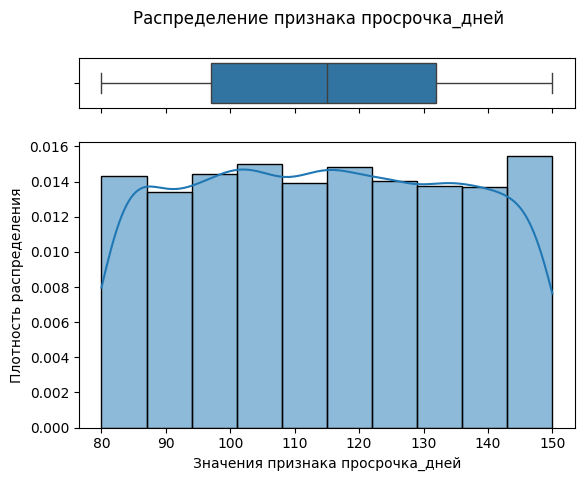

In [9]:
eda_helper.box_hist(df_loan_payment_credit, 'просрочка_дней', bins=10)

Распределение дней просрочки близко к равномерному. Выбросы отсутствуют.

Удалим дубликаты:

In [10]:
eda_helper.drop_duplicates(df_loan_payment_credit)

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено


In [11]:
eda_helper.drop_duplicates(df_loan_payment_credit, ['ID', 'дата_начала_периода'])

Найдено 0 дубликатов по ['ID', 'дата_начала_периода'] столбцам
Дубликатов не обнаружено


Явных дубликатов нет в том числе по подмножеству столбцов. Оценим содержимое колонки ID:

In [12]:
df_loan_payment_credit['ID'].nunique()

5500

В таблице представлена информация о 5500 пользователях с уникальными идентификаторами. 

Теперь узнаем, какое количество записей для каждого пользователя присутствует в датасете (нет ли в датасете аномальных пользователей с большим количеством записей о транзакциях)

### Таблица 2. Месячные транзакции transactions


In [13]:
eda_helper.df_info(df_transactions, 'transactions')

--------------------------------------------------
Описание датасета transactions:
Датасет transactions содержит 577494 строк и 10 столбцов.
Размер датасета transactions в памяти: 46.2 MB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  str    
 1   date        577494 non-null  str    
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), str(2)
memory usage: 44.1 MB
None
--------------------------------------------------
Данные датасета transactions:
----------------------

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,place
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35,head
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61,head
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06,head
1254,IDF54994703,2018-06-01,2408.02,954.09,990.88,4336.24,465.47,1517.43,2932.74,2449.64,random
285672,IDF55122231,2016-01-01,2596.32,2060.18,1062.92,4681.75,832.60,1788.78,3750.44,2363.27,random
360296,IDF55050571,2019-06-01,1121.96,183.30,321.89,937.66,98.54,416.82,265.11,520.36,random
577491,IDF54902735,2019-11-01,7511.65,1218.89,3815.65,6194.13,625.55,2176.77,1730.66,3183.58,tail
577492,IDF54902735,2019-12-01,7134.51,1298.59,2355.14,5801.57,659.36,2703.88,1640.50,3682.00,tail
577493,IDF55140157,2019-12-01,3895.45,1261.54,1643.18,7549.39,850.11,2443.34,4990.17,4308.86,tail


В датасете transactions нет пропущенных значений


Таблица содержит информацию о помесячным тратам клиента по MCC-кодам. При этом в стобце date указана дата месяца за который высчитана сумма трат.

```
- ID — идентификатор клиента.
- date — календарная дата по месяцам.
- MCC_5300 — Оптовики (Ozon, Lamoda, Wildberries и другие)
- MCC_5814 — Фастфуд
- MCC_5812 — Места общественного питания, рестораны
- MCC_5411 — Бакалейные магазины, супермаркеты
- MCC_3990 — Экосистема Яндекса
- MCC_5722 — Бытовое оборудование
- MCC_4900 — Жилищно-коммунальные услуги
- MCC_другое — Остальные категории
```

Это большая таблица (более 500к записей). Cтолбец date требует конвертации. Пропусков нет. Проверим выбросы.

In [14]:
eda_helper.convert_to_datetime(df_transactions, 'date')

Данные в "date" представлены за период 2525 дн. (6.9 л.): 2013-01-01 00:00:00 - 2019-12-01 00:00:00


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90
...,...,...,...,...,...,...,...,...,...,...
577489,IDF54902735,2019-09-01,4255.61,1203.03,3620.57,8919.58,652.29,2273.42,1597.24,4800.25
577490,IDF54902735,2019-10-01,4599.28,794.15,2887.12,5278.12,412.97,1477.75,1025.40,2417.11
577491,IDF54902735,2019-11-01,7511.65,1218.89,3815.65,6194.13,625.55,2176.77,1730.66,3183.58
577492,IDF54902735,2019-12-01,7134.51,1298.59,2355.14,5801.57,659.36,2703.88,1640.50,3682.00


Можно заметить, что:
- 2013-01-01 - 2019-12-01 - диапазон данных в транзакциях
- 2013-11-01 - 2019-12-01 - диапазон данных в таблице с просрочкой - на 10 месяцев меньше.

Проверим на дубликаты:

In [15]:
eda_helper.drop_duplicates(df_transactions)
eda_helper.drop_duplicates(df_transactions, subset=['ID', 'date'])

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено
Найдено 0 дубликатов по ['ID', 'date'] столбцам
Дубликатов не обнаружено


Дубликатов нет.

Оценим уникальные значения столбца ID:

In [16]:
eda_helper.print_unique_values(df_transactions[['ID']])

Уникальные значения всех категориальных признаков:

ID [13500]: IDF54896351, IDF54896355, IDF54896367, IDF54896414, IDF54896457, ...


/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_44273/2264910381.py:253: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


В столбце представлена информация о 13500 идентификаторов клиентов. Это больше, чем в таблице `df_loan_payment_credit`, где их 5500.

Исследуем описательную статистику данной таблицы:

In [17]:
MCC_COLS = ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']
df_transactions.describe()

,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
count,577494,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000
mean,2017-08-08 08:44:17.407349,6177.123479,3507.682295,2993.862550,9263.099506,1128.116742,3604.437043,3682.487182,5414.896895
min,2013-01-01 00:00:00,162.910000,62.180000,67.060000,286.110000,31.900000,108.400000,81.290000,166.260000
25%,2016-06-01 00:00:00,1360.880000,583.480000,611.540000,2139.480000,245.060000,824.942500,700.632500,1250.850000
50%,2017-12-01 00:00:00,2659.590000,1233.110000,1224.530000,4115.385000,476.890000,1590.120000,1397.065000,2398.330000
75%,2019-01-01 00:00:00,6561.467500,3642.392500,3201.612500,9287.545000,1159.520000,3866.050000,3872.412500,5413.530000
max,2019-12-01 00:00:00,86939.400000,55720.690000,47969.570000,101301.950000,14261.490000,54630.190000,52987.530000,60033.550000
std,NaN,8835.871514,5710.755226,4541.119582,12299.732992,1557.157475,5005.896972,5567.979383,7190.882383


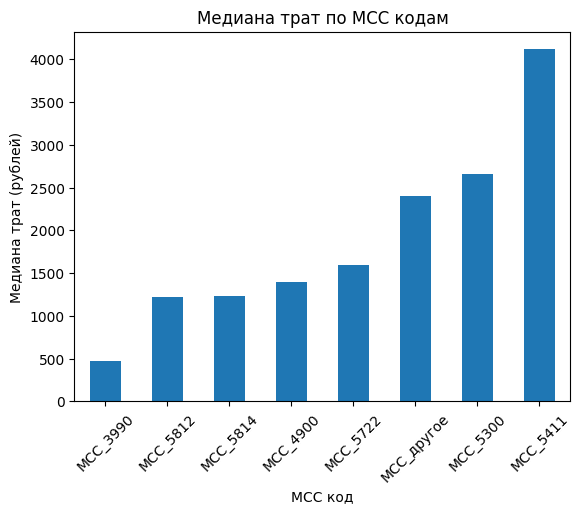

In [18]:
pd.DataFrame(df_transactions[MCC_COLS].describe().loc['50%']).sort_values(['50%']).plot(
    kind='bar',
    legend=False,
    xlabel='MCC код',
    ylabel='Медиана трат (рублей)',
    title='Медиана трат по MCC кодам',
    rot=45,
)
plt.show()

Минимальные/максимальные значения выглядят органично. Самый большой категорией трат у пользователей с кредитами является MCC_5411 - супермаркеты/бакалея. То есть траты на еду.

### Таблица 3. Описание клиента на момент регистрации в банке client_description


In [19]:
eda_helper.df_info(df_client_description)

--------------------------------------------------
Описание датасета :
Датасет  содержит 13500 строк и 5 столбцов.
Размер датасета  в памяти: 540.13 KB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  13500 non-null  str  
 1   возраст             13500 non-null  int64
 2   семейное_положение  13500 non-null  str  
 3   наличие_иждивенцев  13500 non-null  int64
 4   дата_регистрации    13500 non-null  str  
dtypes: int64(2), str(3)
memory usage: 527.5 KB
None
--------------------------------------------------
Данные датасета :
--------------------------------------------------


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,place
0,IDF55109846,41,разведённые,1,2013-05-01,head
1,IDF54900291,45,разведённые,1,2017-12-01,head
2,IDF54995533,34,разведённые,1,2013-11-01,head
2448,IDF55075459,40,есть семья,1,2017-11-01,random
6658,IDF54961196,24,есть семья,1,2019-08-01,random
9699,IDF55068490,43,нет семьи,1,2018-10-01,random
13497,IDF54917881,39,нет семьи,0,2014-12-01,tail
13498,IDF54902735,27,разведённые,0,2014-03-01,tail
13499,IDF55140157,62,разведённые,1,2019-12-01,tail


В датасете  нет пропущенных значений


Содержит столбцы:
- ID — идентификатор клиента.
- возраст — возраст клиента.
- семейное_положение — семейное положение клиента. Три состояния: разведённые, есть семья, нет семьи.
- наличие_иждивенцев — есть ли у клиента лица на финансовом попечении: 1 — да, 0 — нет.
- дата_регистрации — календарная дата начала взаимоотношений банка и клиента.

Необходимо исправить тип столбца с датой регистрации:

In [20]:
eda_helper.convert_to_datetime(df_client_description, 'дата_регистрации')

Данные в "дата_регистрации" представлены за период 2525 дн. (6.9 л.): 2013-01-01 00:00:00 - 2019-12-01 00:00:00


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01
...,...,...,...,...,...
13495,IDF55146629,23,нет семьи,1,2013-05-01
13496,IDF54957110,22,разведённые,1,2017-04-01
13497,IDF54917881,39,нет семьи,0,2014-12-01
13498,IDF54902735,27,разведённые,0,2014-03-01


Диапазон дат совпадает с df_transactions. Пропусков нет. Проверим дубликаты

In [21]:
eda_helper.drop_duplicates(df_client_description)
eda_helper.drop_duplicates(df_client_description, subset=['ID'])


Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено
Найдено 0 дубликатов по ['ID'] столбцам
Дубликатов не обнаружено


Дубликаты отсутствуют.

Проверим уникальные значения кат столбцов:


In [22]:
eda_helper.print_unique_values(
    df_client_description[['семейное_положение']]
)

Уникальные значения всех категориальных признаков:

семейное_положение [3]: есть семья, нет семьи, разведённые


/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_44273/2264910381.py:253: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Значения в столбце семейное_положение соответствует ожиданию.

Проверим числовые столбцы:

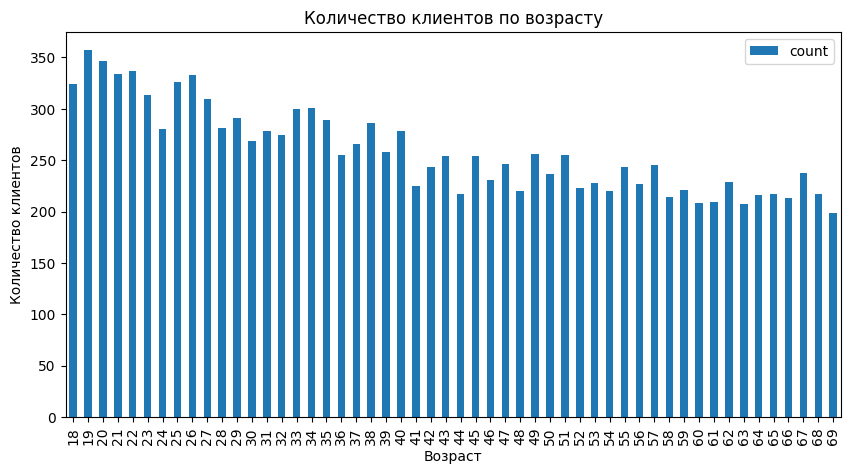

In [23]:
pd.DataFrame(df_client_description['возраст'].value_counts()) \
    .sort_values(by='возраст').plot(
        kind='bar',
        figsize=(10, 5),
        title='Количество клиентов по возрасту',
        xlabel='Возраст',
        ylabel='Количество клиентов',
)
plt.show()

Есть обратная зависимость возраста от количества клиентов с кредитом: чем старше, тем меньше людей берут кредиты. Это может быть связано как с ростом дохода, но могут быть и другие причины, например, социально-демографические.

Выбросов нет.

### Таблица 4. Описание кредита credit_description


In [24]:
eda_helper.df_info(df_credit_description)

--------------------------------------------------
Описание датасета :
Датасет  содержит 13500 строк и 3 столбцов.
Размер датасета  в памяти: 324.13 KB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             13500 non-null  str  
 1   доход          13500 non-null  int64
 2   сумма_кредита  13500 non-null  int64
dtypes: int64(2), str(1)
memory usage: 316.5 KB
None
--------------------------------------------------
Данные датасета :
--------------------------------------------------


,ID,доход,сумма_кредита,place
0,IDF55109846,27035,1960785,head
1,IDF54900291,64502,3375810,head
2,IDF54995533,90477,401700,head
2448,IDF55075459,37957,1274175,random
6658,IDF54961196,107080,1309275,random
9699,IDF55068490,62721,2283990,random
13497,IDF54917881,24748,3663045,tail
13498,IDF54902735,133821,389610,tail
13499,IDF55140157,85200,2709675,tail


В датасете  нет пропущенных значений


Содержит столбцы:
- ID — идентификатор клиента.
- доход — месячный доход клиента на момент взятия кредита в рублях.
- сумма_кредита — сумма кредита, выданного клиенту, в рублях.

Типы данных корректны. Пропусков нет.

Проверим дубликаты:

In [25]:
eda_helper.drop_duplicates(df_credit_description)
eda_helper.drop_duplicates(df_credit_description, subset=['ID'])

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено
Найдено 0 дубликатов по ['ID'] столбцам
Дубликатов не обнаружено


Дубликатов нет. Посмотрим на описательную статистику.

In [26]:
df_credit_description.describe().astype(int)

,доход,сумма_кредита
count,13500,13500
mean,79089,1993383
std,40045,1061381
min,15010,75000
25%,43347,1079328
50%,77991,2032732
75%,113615,2919236
max,149988,3749400


Значения выглядят органичными, выбросов нет. Построим гистрограмму распределения для визуализации:

               доход
count   13500.000000
mean    79089.268593
std     40045.549462
min     15010.000000
25%     43347.000000
50%     77991.500000
75%    113615.500000
max    149988.000000


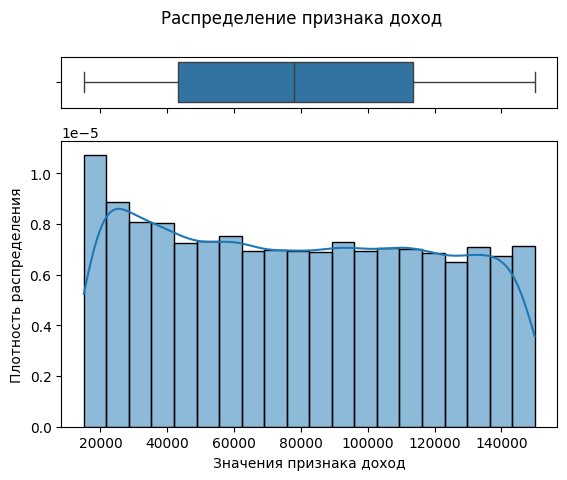

In [27]:
eda_helper.box_hist(df_credit_description, 'доход')

Чуть больше людей с низким доходом берут кредит, это логично.

       сумма_кредита
count   1.350000e+04
mean    1.993383e+06
std     1.061381e+06
min     7.500000e+04
25%     1.079329e+06
50%     2.032732e+06
75%     2.919236e+06
max     3.749400e+06


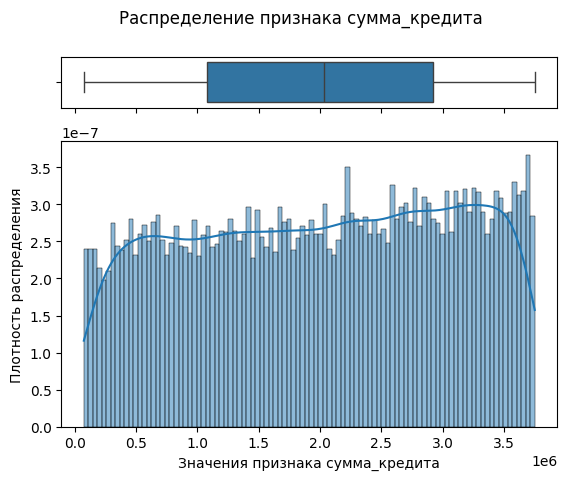

In [28]:
eda_helper.box_hist(df_credit_description, 'сумма_кредита', bins=100)

В основном люди берут кредиты от 2.5 млн до 3. Кредиты относятся к ипотечному кредитованию судя по размеру.

### Таблица 5. Данные о наличии ипотеки mortgage_presence


In [29]:
eda_helper.df_info(df_mortgage_presence)

--------------------------------------------------
Описание датасета :
Датасет  содержит 6609 строк и 3 столбцов.
Размер датасета  в памяти: 158.75 KB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               6609 non-null   str  
 1   дата_открытия    6609 non-null   str  
 2   наличие_ипотеки  6609 non-null   int64
dtypes: int64(1), str(2)
memory usage: 155.0 KB
None
--------------------------------------------------
Данные датасета :
--------------------------------------------------


,ID,дата_открытия,наличие_ипотеки,place
0,IDF54896351,2013-03-01,1,head
1,IDF54896367,2018-01-01,1,head
2,IDF54896414,2018-02-01,1,head
3953,IDF55047613,2014-03-01,1,random
4015,IDF55049755,2019-10-01,1,random
5629,IDF55112334,2016-09-01,1,random
6606,IDF55151575,2014-02-01,1,tail
6607,IDF55151597,2019-01-01,1,tail
6608,IDF55151634,2018-10-01,1,tail


В датасете  нет пропущенных значений


В датасете 6.6к строк.

Содержит столбцы:
- ID — идентификатор клиента.
- дата_открытия — календарная дата, когда клиент оформил ипотеку.
- наличие_ипотеки — есть ли у клиента ипотека: 1 — да, 0 — нет.

Требуется скорректировать тип столбца с датой:

In [30]:
eda_helper.convert_to_datetime(df_mortgage_presence, 'дата_открытия')

Данные в "дата_открытия" представлены за период 2525 дн. (6.9 л.): 2013-01-01 00:00:00 - 2019-12-01 00:00:00


,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1
...,...,...,...
6604,IDF55151532,2019-05-01,1
6605,IDF55151572,2017-03-01,1
6606,IDF55151575,2014-02-01,1
6607,IDF55151597,2019-01-01,1


Проверим дубликаты:

In [31]:
eda_helper.drop_duplicates(df_mortgage_presence)
eda_helper.drop_duplicates(df_mortgage_presence, subset=['ID'])


Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено
Найдено 0 дубликатов по ['ID'] столбцам
Дубликатов не обнаружено


Дубликатов нет. Уникальные значения в столбце наличие_ипотеки:

In [32]:
df_mortgage_presence['наличие_ипотеки'].value_counts()

наличие_ипотеки
1    6609
Name: count, dtype: int64

Все записи в таблице - это факт наличия ипотеки у клиента. Если запись для какого-то клиента отсутствует, то он не имеет ипотеки.

### Таблица 6. Данные о кредитном рейтинге клиента credit_rating


In [33]:
eda_helper.df_info(df_credit_rating, 'credit_rating')

--------------------------------------------------
Описание датасета credit_rating:
Датасет credit_rating содержит 577494 строк и 3 столбцов.
Размер датасета credit_rating в памяти: 13.86 MB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ID                 577494 non-null  str  
 1   date               577494 non-null  str  
 2   кредитный_рейтинг  577494 non-null  int64
dtypes: int64(1), str(2)
memory usage: 13.2 MB
None
--------------------------------------------------
Данные датасета credit_rating:
--------------------------------------------------


,ID,date,кредитный_рейтинг,place
0,IDF55109846,2013-05-01,692,head
1,IDF55109846,2013-06-01,688,head
2,IDF55109846,2013-07-01,666,head
1254,IDF54994703,2018-06-01,515,random
285672,IDF55122231,2016-01-01,637,random
360296,IDF55050571,2019-06-01,579,random
577491,IDF54902735,2019-11-01,582,tail
577492,IDF54902735,2019-12-01,586,tail
577493,IDF55140157,2019-12-01,575,tail


В датасете credit_rating нет пропущенных значений


Содержит столбцы:
- ID — идентификатор клиента.
- date — дата наблюдения (первое число месяца).
- кредитный_рейтинг — числовой кредитный рейтинг клиента на данный месяц.

Таблица является временным рядом: для каждого клиента присутствует несколько строк — по одной на каждый месяц наблюдения. Столбец date требует преобразования из строки в тип datetime:

In [34]:
eda_helper.convert_to_datetime(df_credit_rating, 'date')

Данные в "date" представлены за период 2525 дн. (6.9 л.): 2013-01-01 00:00:00 - 2019-12-01 00:00:00


,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688
...,...,...,...
577489,IDF54902735,2019-09-01,592
577490,IDF54902735,2019-10-01,592
577491,IDF54902735,2019-11-01,582
577492,IDF54902735,2019-12-01,586


Проверим дубликаты:

In [35]:
eda_helper.drop_duplicates(df_credit_rating)
eda_helper.drop_duplicates(df_credit_rating, subset=['ID', 'date'])

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено
Найдено 0 дубликатов по ['ID', 'date'] столбцам
Дубликатов не обнаружено


Дубликатов нет. Оценим количество уникальных клиентов в таблице:

In [36]:
df_credit_rating['ID'].nunique()

13500

В таблице больше пользователей, чем в данных о просрочках кредитов, соответственно в ней присутствуют пользователи без просрочек.

Посмотрим, сколько записей приходится на каждого клиента:

In [37]:
records_per_client = df_credit_rating.groupby('ID').size()
records_per_client.describe().astype(int)

count    13500
mean        42
std         24
min          1
25%         22
50%         43
75%         64
max         84
dtype: int64

На каждого пользователя в медиане приходится 43 записи, соответствующие количеству месяцев со значением измененного кредитного рейтинга. То есть примерно по 3.5 года записей на каждого пользователя.

Построим распределение значений кредитного рейтинга:

       кредитный_рейтинг
count      577494.000000
mean          603.190961
std            64.358896
min           343.000000
25%           558.000000
50%           600.000000
75%           646.000000
max           900.000000


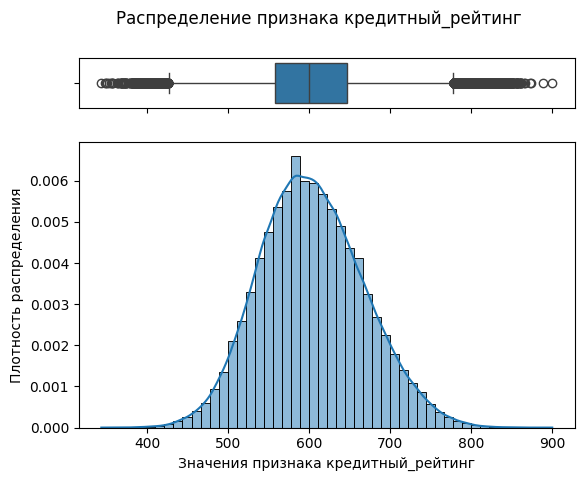

In [38]:
eda_helper.box_hist(df_credit_rating, 'кредитный_рейтинг', bins=50)

Кредитный рейтинг — числовой показатель, отражающий кредитоспособность клиента в конкретный месяц. Таблица содержит ~577 тыс. строк, что соответствует временному ряду: для каждого клиента хранится история рейтинга по месяцам. Пропусков нет. Дубликатов по паре (ID, date) нет — каждый клиент имеет не более одной записи в месяц. Распределение рейтинга позволяет оценить типичный диапазон значений: от 300 до 900.

Из открытых источников можно узнать, что хорошим считается рейтинг 700-800 баллов и выше. Рейтинг 500-600 баллов свидетельствует о высоком риске отказа клиенту в кредитовании.

### Таблица 7. Данные о макроэкономических показателях России macro_data


In [39]:
eda_helper.df_info(df_macro_data, 'macro_data')

--------------------------------------------------
Описание датасета macro_data:
Датасет macro_data содержит 84 строк и 4 столбцов.
Размер датасета macro_data в памяти: 2.82 KB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     str    
 1   учетная_ставка       84 non-null     float64
 2   уровень_безработицы  84 non-null     float64
 3   инфляция             84 non-null     float64
dtypes: float64(3), str(1)
memory usage: 2.8 KB
None
--------------------------------------------------
Данные датасета macro_data:
--------------------------------------------------


,date,учетная_ставка,уровень_безработицы,инфляция,place
0,2013-01-01,5.500000,5.7,0.97,head
1,2013-02-01,5.500000,5.8,0.56,head
2,2013-03-01,5.500000,5.9,0.34,head
25,2015-02-01,15.000000,5.7,2.22,random
50,2017-03-01,9.943182,5.6,0.13,random
76,2019-05-01,7.750000,4.6,0.34,random
81,2019-10-01,6.913043,4.5,0.13,tail
82,2019-11-01,6.500000,4.6,0.28,tail
83,2019-12-01,6.363636,4.7,0.36,tail


В датасете macro_data нет пропущенных значений


Содержит столбцы:
- date — месяц и год, на которые актуальны указанные показатели.
- учетная_ставка — учётная ставка в процентах.
- уровень_безработицы — уровень безработицы в процентах.
- инфляция — инфляция в процентах.

Таблица содержит макроэкономические показатели по месяцам без привязки к конкретному клиенту. Столбец date требует преобразования из строки в тип datetime:

In [40]:
eda_helper.convert_to_datetime(df_macro_data, 'date')

Данные в "date" представлены за период 2525 дн. (6.9 л.): 2013-01-01 00:00:00 - 2019-12-01 00:00:00


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.500000,5.7,0.97
1,2013-02-01,5.500000,5.8,0.56
2,2013-03-01,5.500000,5.9,0.34
3,2013-04-01,5.500000,5.5,0.51
4,2013-05-01,5.500000,5.4,0.66
...,...,...,...,...
79,2019-08-01,7.250000,4.4,-0.24
80,2019-09-01,7.059524,4.3,-0.16
81,2019-10-01,6.913043,4.5,0.13
82,2019-11-01,6.500000,4.6,0.28


Проверим дубликаты:

In [41]:
eda_helper.drop_duplicates(df_macro_data)
eda_helper.drop_duplicates(df_macro_data, subset=['date'])

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено
Найдено 0 дубликатов по ['date'] столбцам
Дубликатов не обнаружено


Дубликатов нет. Посмотрим на описательную статистику числовых столбцов:

In [42]:
df_macro_data.describe()

,date,учетная_ставка,уровень_безработицы,инфляция
count,84,84.000000,84.000000,84.000000
mean,2016-06-16 01:08:34.285714,8.638517,5.175000,0.527500
min,2013-01-01 00:00:00,5.500000,4.300000,-0.540000
25%,2014-09-23 12:00:00,7.250000,4.900000,0.262500
50%,2016-06-16 00:00:00,7.750000,5.200000,0.425000
75%,2018-03-08 18:00:00,10.329545,5.500000,0.635000
max,2019-12-01 00:00:00,17.000000,6.000000,3.850000
std,NaN,2.466112,0.409488,0.570189


Значения выглядят органичными, выбросов нет.

Построим распределения числовых показателей:

       учетная_ставка
count       84.000000
mean         8.638517
std          2.466112
min          5.500000
25%          7.250000
50%          7.750000
75%         10.329545
max         17.000000


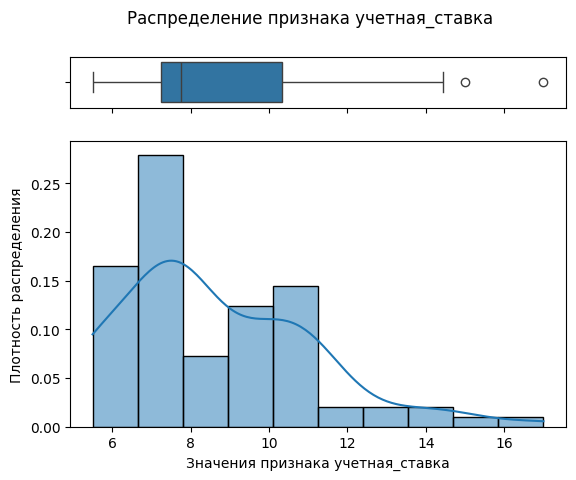

       уровень_безработицы
count            84.000000
mean              5.175000
std               0.409488
min               4.300000
25%               4.900000
50%               5.200000
75%               5.500000
max               6.000000


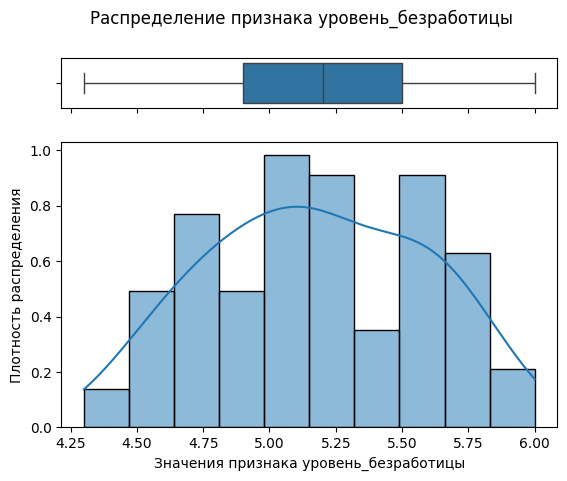

        инфляция
count  84.000000
mean    0.527500
std     0.570189
min    -0.540000
25%     0.262500
50%     0.425000
75%     0.635000
max     3.850000


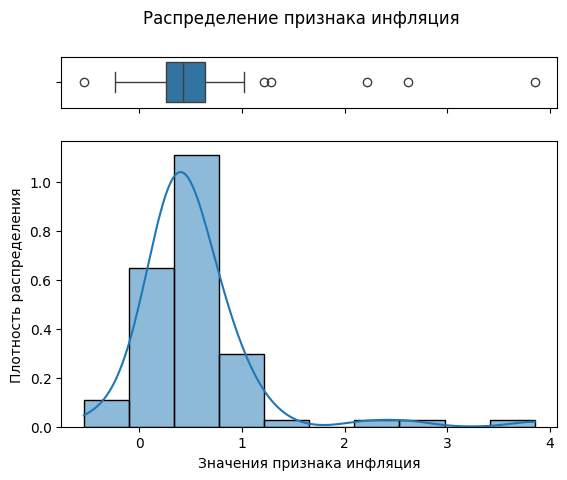

In [43]:
for col in ['учетная_ставка', 'уровень_безработицы', 'инфляция']:
    eda_helper.box_hist(df_macro_data, col, bins=10)

Проверим как менялись макроэкономические показатели со временем:

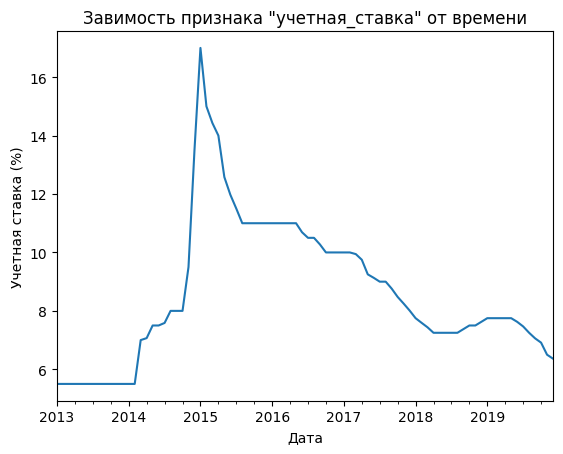

In [44]:
eda_helper.time_line(df_macro_data, 'date', 'учетная_ставка', 'Учетная ставка (%)')

Учетная ставка представлена за 2013-2020 годы и имеет исторический максимум в 2015 году.

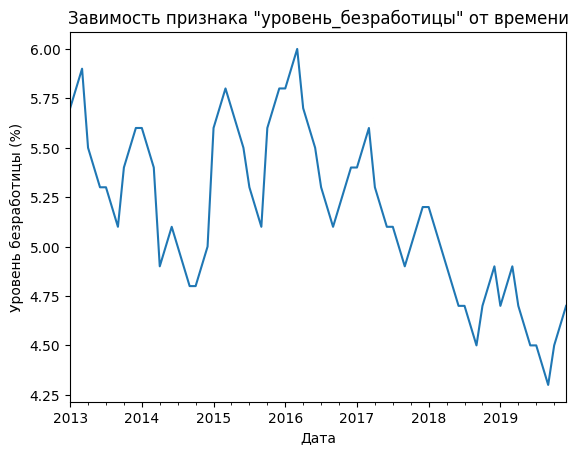

In [45]:
eda_helper.time_line(df_macro_data, 'date', 'уровень_безработицы', 'Уровень безработицы (%)')

Уровень безроботиты имеет сезонные колебания и находится в окрестности 5%.

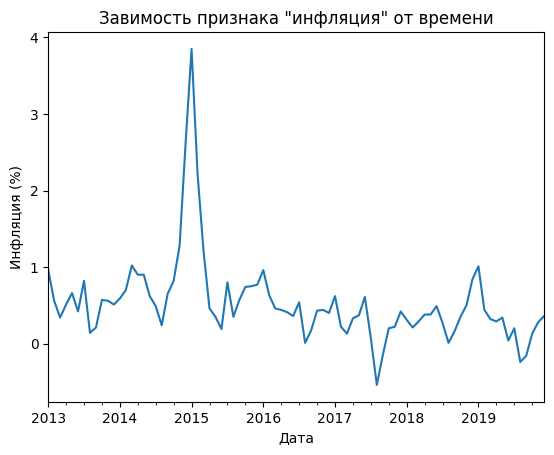

In [46]:
eda_helper.time_line(df_macro_data, 'date', 'инфляция', 'Инфляция (%)')

Исторические данные по инфляции также имеют максимум в 2015 году как и ключевая ставка

Таблица содержит 84 строки — по одной на каждый месяц наблюдаемого периода. Каждая строка описывает макроэкономическую ситуацию в стране: учётную ставку, уровень безработицы и инфляцию. Таблица не привязана к конкретным клиентам и будет присоединяться к итоговому датасету по дате. Пропусков и дубликатов нет. Значения выглядят реалистично для российской экономики за рассматриваемый период.

### Таблица 8. Данные о дате проведения поведенческого скоринга cohort_grid


In [47]:
eda_helper.df_info(df_cohort_grid, 'cohort_grid')

--------------------------------------------------
Описание датасета cohort_grid:
Датасет cohort_grid содержит 577494 строк и 2 столбцов.
Размер датасета cohort_grid в памяти: 9.24 MB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ID          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB
None
--------------------------------------------------
Данные датасета cohort_grid:
--------------------------------------------------


,ID,score_date,place
0,IDF55109846,2013-05-01,head
1,IDF55109846,2013-06-01,head
2,IDF55109846,2013-07-01,head
1254,IDF54994703,2018-06-01,random
285672,IDF55122231,2016-01-01,random
360296,IDF55050571,2019-06-01,random
577491,IDF54902735,2019-11-01,tail
577492,IDF54902735,2019-12-01,tail
577493,IDF55140157,2019-12-01,tail


В датасете cohort_grid нет пропущенных значений


Содержит столбцы:
- ID — идентификатор клиента.
- score_date — дата скоринга.

Таблица задаёт сетку наблюдений: для каждого клиента перечислены все даты, на которые нужно рассчитать целевую переменную и собрать признаки. Столбец score_date требует преобразования из строки в тип datetime:

In [48]:
eda_helper.convert_to_datetime(df_cohort_grid, 'score_date')

Данные в "score_date" представлены за период 2525 дн. (6.9 л.): 2013-01-01 00:00:00 - 2019-12-01 00:00:00


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01
...,...,...
577489,IDF54902735,2019-09-01
577490,IDF54902735,2019-10-01
577491,IDF54902735,2019-11-01
577492,IDF54902735,2019-12-01


Проверим дубликаты:

In [49]:
eda_helper.drop_duplicates(df_cohort_grid)
eda_helper.drop_duplicates(df_cohort_grid, subset=['ID', 'score_date'])

Найдено 0 дубликатов по всем столбцам
Дубликатов не обнаружено
Найдено 0 дубликатов по ['ID', 'score_date'] столбцам
Дубликатов не обнаружено


Дубликатов нет. Оценим количество уникальных клиентов:

In [50]:
df_cohort_grid['ID'].nunique()

13500

Посмотрим, сколько дат скоринга приходится на каждого клиента:

In [51]:
records_per_client_cg = df_cohort_grid.groupby('ID').size()
records_per_client_cg.describe().astype(int)

count    13500
mean        42
std         24
min          1
25%         22
50%         43
75%         64
max         84
dtype: int64

Таблица содержит ~577 тыс. строк и задаёт сетку наблюдений: для каждого клиента перечислены все месяцы, на которые проводится скоринг. Пропусков и дубликатов по паре (ID, score_date) нет. Таблица служит основой для формирования итогового датасета — к ней будут присоединяться все остальные источники данных.

<a id="dataset"></a>

## Формирование датасета

### Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

#### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.



Поэтапро сформируем целевую переменную для нескольких клиентов банка для отладки:
1. Первым шагом отбросим гипотетически возможные повторные периоды просрочки >=90 дней для пользователей, оставив только первый.
2. Выделим интересных клиентов, на которых отладим формирование целевой переменной (без просрочек, с просрочкой >=90 дней, с просрочкой <90 дней)
3. Сформируем целевую для всего датасета.

Несмотря на то, что в таблице df_loan_payment_credit все клиентские ID уникальны (было проверено на этапе исследовательского анализа), необходимо перестраховаться и исходить из предположения, что у клиента может быть несколько эпизодов с просрочками от 90 дней. Поэтому нужно взять первый по времени возникновения эпизод в таблице с просрочками.

In [52]:
# Находим первый период с просрочкой больше 90 дней для пользователя
df_first_period = (
    df_loan_payment_credit[df_loan_payment_credit['просрочка_дней'] >= 90]
    .groupby(['ID'])
    .agg({'дата_начала_периода': 'min'})
    .reset_index()
    .rename(columns={'дата_начала_периода': 'первая_просрочка_90'})
)

# джойним с основной таблицей с просрочками
df_result = df_loan_payment_credit.merge(df_first_period, on='ID', how='left')

# оставляем только те периоды, где просрочка была меньше 90 дней
# или это первая просрочка >=90 дней
df_result = df_result[
    df_result['первая_просрочка_90'].isna() |
    (df_result['дата_начала_периода'] <= df_result['первая_просрочка_90'])
].drop(columns=['первая_просрочка_90'])

df_loan_payment_credit = df_result.copy()

Определим интересных клиентов, на которых отладим формирование целевой переменной:

In [53]:
df_loan_payment_credit.sample(10, random_state=RANDOM_STATE)

,ID,дата_начала_периода,просрочка_дней
3865,IDF54965892,2014-03-01,102
3283,IDF55116547,2019-02-01,145
174,IDF55054206,2017-06-01,143
1736,IDF54921885,2019-11-01,134
5271,IDF55146226,2019-05-01,106
3261,IDF55076822,2018-06-01,87
3504,IDF54909028,2017-05-01,125
5230,IDF55022454,2014-09-01,112
3835,IDF54992478,2019-11-01,146
4436,IDF55132373,2014-05-01,148


Интересны клиенты
- IDF55076822 - у него просрочка меньше 87 дней.
- IDF55146226 - просрочка больше 90 дней.
- IDF55013031 - просрочки отсутствуют.


Проверим данные из таблицы просрочек для указанных клиентов клиента:

In [54]:
interesting_clients = {
    'less_90' : 'IDF55076822',
    'more_90' : 'IDF55146226',
    'no_overdue' : 'IDF55013031'
}
df_loan_payment_credit[df_loan_payment_credit['ID'].isin(interesting_clients.values())]

,ID,дата_начала_периода,просрочка_дней
3261,IDF55076822,2018-06-01,87
5271,IDF55146226,2019-05-01,106


Для последнего клиента даты просрочки нет, как и ожидается.

Присоединим к cohort_grid таблицу с данными о просрочке кредитов, далее сформируем целевую переменную и рассмотрим результат по каждому клиенту:

In [55]:
df = df_cohort_grid \
    .merge(df_loan_payment_credit, on='ID', how='left') \
    .sort_values(by='score_date')
df.head(10)

,ID,score_date,дата_начала_периода,просрочка_дней
197982,IDF54905698,2013-01-01,2014-09-01,92.0
165362,IDF55106956,2013-01-01,2014-05-01,145.0
166188,IDF54898248,2013-01-01,2014-04-01,129.0
412050,IDF55102282,2013-01-01,NaT,NaN
399640,IDF54927506,2013-01-01,2014-02-01,85.0
109265,IDF55076663,2013-01-01,2014-05-01,150.0
468065,IDF55058674,2013-01-01,NaT,NaN
399270,IDF54914187,2013-01-01,NaT,NaN
42274,IDF55130992,2013-01-01,NaT,NaN
170362,IDF55053634,2013-01-01,2014-09-01,149.0


Сформируем целевую переменную по следующим правилам:

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

In [56]:
target_mask = (df['просрочка_дней'] >= 90) \
    & (df['дата_начала_периода'].between(df['score_date'], df['score_date'] + pd.Timedelta(days=365)))
df = df.assign(target=target_mask.astype(int))
df.head(10)

,ID,score_date,дата_начала_периода,просрочка_дней,target
197982,IDF54905698,2013-01-01,2014-09-01,92.0,0
165362,IDF55106956,2013-01-01,2014-05-01,145.0,0
166188,IDF54898248,2013-01-01,2014-04-01,129.0,0
412050,IDF55102282,2013-01-01,NaT,NaN,0
399640,IDF54927506,2013-01-01,2014-02-01,85.0,0
109265,IDF55076663,2013-01-01,2014-05-01,150.0,0
468065,IDF55058674,2013-01-01,NaT,NaN,0
399270,IDF54914187,2013-01-01,NaT,NaN,0
42274,IDF55130992,2013-01-01,NaT,NaN,0
170362,IDF55053634,2013-01-01,2014-09-01,149.0,0


Рассмотрим полученный таргет по каждому клиенту. Сначала выберем данные по клиенту без просрочки:

In [57]:
display(df[df['ID'] == interesting_clients['no_overdue']].sample(10, random_state=RANDOM_STATE))
df[df['ID'] == interesting_clients['no_overdue']]['target'].sum()

,ID,score_date,дата_начала_периода,просрочка_дней,target
420968,IDF55013031,2015-02-01,NaT,NaN,0
420981,IDF55013031,2016-03-01,NaT,NaN,0
420977,IDF55013031,2015-11-01,NaT,NaN,0
421002,IDF55013031,2017-12-01,NaT,NaN,0
420994,IDF55013031,2017-04-01,NaT,NaN,0
420973,IDF55013031,2015-07-01,NaT,NaN,0
421010,IDF55013031,2018-08-01,NaT,NaN,0
420958,IDF55013031,2014-04-01,NaT,NaN,0
420948,IDF55013031,2013-06-01,NaT,NaN,0
420986,IDF55013031,2016-08-01,NaT,NaN,0


np.int64(0)

Для клиента без просрочки сетка временного рядя сформирована с таргетом = 0. Дата начала просрочки и количество дней ожидаемо пропущены.

Рассмотрим таргет для пользователя с количеством дней просрочки меньше 90.

In [58]:
display(df[df['ID'] == interesting_clients['less_90']])
df[df['ID'] == interesting_clients['less_90']]['target'].sum()

,ID,score_date,дата_начала_периода,просрочка_дней,target
340680,IDF55076822,2017-04-01,2018-06-01,87.0,0
340681,IDF55076822,2017-05-01,2018-06-01,87.0,0
340682,IDF55076822,2017-06-01,2018-06-01,87.0,0
340683,IDF55076822,2017-07-01,2018-06-01,87.0,0
340684,IDF55076822,2017-08-01,2018-06-01,87.0,0
340685,IDF55076822,2017-09-01,2018-06-01,87.0,0
340686,IDF55076822,2017-10-01,2018-06-01,87.0,0
340687,IDF55076822,2017-11-01,2018-06-01,87.0,0
340688,IDF55076822,2017-12-01,2018-06-01,87.0,0
340689,IDF55076822,2018-01-01,2018-06-01,87.0,0


np.int64(0)

Таргет сформирован корректно.

Рассмотрим пользователя с просрочкой более 90 дней:

In [59]:
display(df[df['ID'] == interesting_clients['more_90']].sort_values(by='score_date'))
df[df['ID'] == interesting_clients['more_90']]['target'].sum()

,ID,score_date,дата_начала_периода,просрочка_дней,target
553377,IDF55146226,2018-09-01,2019-05-01,106.0,1
553378,IDF55146226,2018-10-01,2019-05-01,106.0,1
553379,IDF55146226,2018-11-01,2019-05-01,106.0,1
553380,IDF55146226,2018-12-01,2019-05-01,106.0,1
553381,IDF55146226,2019-01-01,2019-05-01,106.0,1
553382,IDF55146226,2019-02-01,2019-05-01,106.0,1
553383,IDF55146226,2019-03-01,2019-05-01,106.0,1
553384,IDF55146226,2019-04-01,2019-05-01,106.0,1
553385,IDF55146226,2019-05-01,2019-05-01,106.0,1
553386,IDF55146226,2019-06-01,2019-05-01,106.0,0


np.int64(9)

На момент 2018-09-01 у клиента была просрочка 106 дней, начавшаяся 2019-05-01 (менее года назад), поэтому таргет равен 1.
В момент скоринга 2019-05-01 у клиента все еще была просрочка 106 дней.
В момент скоринга 2019-06-01 условие, что дата начала периода попадает (2019-05-01) попадает в интервал `[score_date, score_date + 365 дней)`, таргет равен 0. И так далее.

Таким образом, таргет сформирован корректно.

Присоединим описание клиента при регистрации в банке:

In [60]:
df = df.merge(df_client_description, on='ID', how='left')
df.sample(10, random_state=RANDOM_STATE)

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
1254,IDF55090491,2013-04-01,NaT,NaN,0,50,есть семья,1,2013-04-01
360296,IDF55058213,2018-07-01,NaT,NaN,0,51,есть семья,1,2014-06-01
285672,IDF54970823,2017-11-01,NaT,NaN,0,19,разведённые,0,2013-05-01
345401,IDF55020904,2018-05-01,NaT,NaN,0,61,разведённые,0,2013-09-01
345688,IDF55135864,2018-05-01,NaT,NaN,0,49,есть семья,1,2014-06-01
228000,IDF54921203,2017-05-01,2016-08-01,125.0,0,29,есть семья,0,2015-09-01
138229,IDF54903060,2016-05-01,NaT,NaN,0,68,разведённые,0,2014-06-01
420985,IDF55092927,2018-12-01,NaT,NaN,0,69,разведённые,0,2013-05-01
398065,IDF54980431,2018-10-01,NaT,NaN,0,64,есть семья,0,2017-11-01
484271,IDF55116757,2019-05-01,NaT,NaN,0,38,есть семья,0,2013-05-01


Присоединим данные о кредите:

In [61]:
df = df.merge(df_credit_description, on='ID', how='left')
df.sample(10, random_state=RANDOM_STATE)

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита
1254,IDF55090491,2013-04-01,NaT,NaN,0,50,есть семья,1,2013-04-01,147768,3317745
360296,IDF55058213,2018-07-01,NaT,NaN,0,51,есть семья,1,2014-06-01,37724,2654100
285672,IDF54970823,2017-11-01,NaT,NaN,0,19,разведённые,0,2013-05-01,120601,169830
345401,IDF55020904,2018-05-01,NaT,NaN,0,61,разведённые,0,2013-09-01,51842,1658340
345688,IDF55135864,2018-05-01,NaT,NaN,0,49,есть семья,1,2014-06-01,54157,477000
228000,IDF54921203,2017-05-01,2016-08-01,125.0,0,29,есть семья,0,2015-09-01,42248,2143125
138229,IDF54903060,2016-05-01,NaT,NaN,0,68,разведённые,0,2014-06-01,106581,3140790
420985,IDF55092927,2018-12-01,NaT,NaN,0,69,разведённые,0,2013-05-01,119162,1422045
398065,IDF54980431,2018-10-01,NaT,NaN,0,64,есть семья,0,2017-11-01,63837,3130680
484271,IDF55116757,2019-05-01,NaT,NaN,0,38,есть семья,0,2013-05-01,116804,1589475


Присоединим данные о наличии ипотеки:

In [62]:
df = df.merge(df_mortgage_presence, on='ID', how='left')
df[df['ID'] == interesting_clients['more_90']]

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки
384879,IDF55146226,2018-09-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
393579,IDF55146226,2018-10-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
406820,IDF55146226,2018-11-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
422448,IDF55146226,2018-12-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
434127,IDF55146226,2019-01-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
441464,IDF55146226,2019-02-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
449598,IDF55146226,2019-03-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
470730,IDF55146226,2019-04-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
479481,IDF55146226,2019-05-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0
486983,IDF55146226,2019-06-01,2019-05-01,106.0,0,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0


Далее необходимо сформировать оставшиеся признаки по таблицам, хранящим данные во временных рядах:
- данных о смене кредитного рейтинга
- данных о макроэкономических показателях
- данных о месячных тратах пользователя по разным категориям

#### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

Присоединим данные о кредитном рейтинге пользователя на момент поведенческого скоринга. Кредитный рейтинт вероятнее всего рассчитывается каждый день или чаще (если бы он рассчитывался реже, то это дало бы возможность моженничества). Это означает, что присоединять данные по клиенту можно по дате, так как на момент скоринга клиента его кредитный рейтинг известен.

In [63]:
df = df.merge(df_credit_rating, left_on=['ID', 'score_date'], right_on=['ID', 'date'], how='left')
# удалим колонку с датой кредитного рейтинга:
df.drop(columns=['date'], inplace=True)

In [64]:
# проверим кредитный рейинг с просрочкой:
df[df['ID'] == interesting_clients['more_90']]

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг
384879,IDF55146226,2018-09-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,710
393579,IDF55146226,2018-10-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,694
406820,IDF55146226,2018-11-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,659
422448,IDF55146226,2018-12-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,652
434127,IDF55146226,2019-01-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,665
441464,IDF55146226,2019-02-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,669
449598,IDF55146226,2019-03-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,644
470730,IDF55146226,2019-04-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,643
479481,IDF55146226,2019-05-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,621
486983,IDF55146226,2019-06-01,2019-05-01,106.0,0,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,595


Присоединим данные о маркроэкономических показателях России. Здесь также принимаем допущение, что макроэкономические показатели известны на момент указанной даты, то есть вычисляются ежедневно, но представлены в таблице по указанным датам, что дает возможность присоединения к итоговой таблице по дате скоринга без утечек информации о будущем.

In [65]:
df = df.merge(df_macro_data, left_on=['score_date'], right_on=['date'], how='left')
# удалим колонку с датой от присоединенной таблицы:
df.drop(columns=['date'], inplace=True)


Проверим присоединенные данные:

In [66]:
df[df['ID'] == interesting_clients['more_90']]

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция
384879,IDF55146226,2018-09-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,710,7.375000,4.5,0.16
393579,IDF55146226,2018-10-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,694,7.500000,4.7,0.35
406820,IDF55146226,2018-11-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,659,7.500000,4.8,0.50
422448,IDF55146226,2018-12-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,652,7.625000,4.9,0.84
434127,IDF55146226,2019-01-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,665,7.750000,4.7,1.01
441464,IDF55146226,2019-02-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,669,7.750000,4.8,0.44
449598,IDF55146226,2019-03-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,644,7.750000,4.9,0.32
470730,IDF55146226,2019-04-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,643,7.750000,4.7,0.29
479481,IDF55146226,2019-05-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,621,7.750000,4.6,0.34
486983,IDF55146226,2019-06-01,2019-05-01,106.0,0,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,595,7.625000,4.5,0.04


Данные присоединены корректно.

Присоединим данные о тратах клиента из таблицы df_transactions. В данной таблице на указанную дату представлена сумма трат по разным MCC кодам за ТЕКУЩИЙ месяц, указанный в `date`. По значению `date` мы соединим таблицу с целевым датасетом по колонке `score_date`. Чтобы избежать заглядывания в будущее при обучении модели и ее применении, необходимо иметь в виду, что траты  имеем данные о тратах только за предыдущий месяц, то есть необходимо насчитывать фичи со смещением на 1.

In [67]:
df_transactions[df_transactions['ID'] == interesting_clients['more_90']][['ID', 'date', 'MCC_5300']].head(3)

,ID,date,MCC_5300
553377,IDF55146226,2018-09-01,10328.08
553378,IDF55146226,2018-10-01,10029.22
553379,IDF55146226,2018-11-01,12318.86


Теперь можно присоединить данные к целевому датасету по дате:

In [68]:
df = df.merge(df_transactions, left_on=['ID', 'score_date'], right_on=['ID', 'date'], how='left')
# удалим колонку с датой от присоединенной таблицы:
df.drop(columns=['date'], inplace=True)

# проверим присоединенные данные
df[df['ID'] == interesting_clients['more_90']].head(3)

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
384879,IDF55146226,2018-09-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,710,7.375,4.5,0.16,10328.08,3671.84,3775.46,18008.94,1821.46,6609.67,11705.34,9983.16
393579,IDF55146226,2018-10-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,694,7.500,4.7,0.35,10029.22,8627.39,3972.32,17374.97,3533.36,6211.66,12016.32,10346.71
406820,IDF55146226,2018-11-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,659,7.500,4.8,0.50,12318.86,16228.78,5082.21,22905.39,4246.40,7824.08,15187.46,12507.78


Данные присоединены корректно. Утечки данных нет.

### Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

Добавим новые признаки, которые выглядят наиболее перспективно с точки зрения обучения модели:
1. `month_outcome` - сумма месячных трат клиента по всем MCC кодам за ПРЕДЫДУЩИЙ по отношению к `score_date` период
2. `outcome_to_income` - Отношения суммы месячных трат от дохода клиента - показывает насколько сильно тратыза предыдущий период расходуют доход клиента. 
3. `loan_to_income` - Долговая нагрузка: сумма кредита / доход
4. `client_tenure_days` - сколько дней клиент является клиентом банка на момент `score_date`
5. `credit_rating_trend_3m` - как менялся кредитный рейтинг клиента за последние 3 месяца
6. `rolling_month_outcome_3m` - скользщее среднее месячных трат клиента за последние 3 месяца

In [69]:
def create_time_series_features(df):
    df['month_outcome_current_month'] =  (
        df['MCC_5300'] +
        df['MCC_5814'] +
        df['MCC_5812'] +
        df['MCC_5411'] +
        df['MCC_3990'] +
        df['MCC_5722'] +
        df['MCC_4900'] +
        df['MCC_другое']
    )
    # получаем траты за предыдущий период и удаляем за текущий
    df['month_outcome'] = df.groupby('ID')['month_outcome_current_month'].shift(1)
    df.drop(columns=['month_outcome_current_month'], inplace=True)

    df['outcome_to_income'] = df['month_outcome'] / df['доход']
    df['loan_to_income'] = df['сумма_кредита'] / df['доход']

    df['client_tenure_days'] = (df['score_date'] - df['дата_регистрации']).dt.days

    df['credit_rating_lag_3m'] = df.groupby('ID')['кредитный_рейтинг'].shift(3)
    df['credit_rating_trend_3m'] = (
        df['кредитный_рейтинг'] - df['credit_rating_lag_3m']
    )
    df.drop(columns=['credit_rating_lag_3m'], inplace=True)
    # добавим так же флаг пропуска в данном столбце, чтобы модель могла отличить 0 изменение рейтинга от пустого значения
    df['credit_rating_trend_3m_missing'] = df['credit_rating_trend_3m'].isna().astype(int)

    df['rolling_month_outcome_3m'] = df.groupby('ID')['month_outcome'] \
        .rolling(3, min_periods=1) \
        .mean() \
        .droplevel(0)
    return df

На этапе обработки признаков заполним пропуски в данном столбце специальным значением.

Проверим вычисленные признаки:

In [70]:
df_tmp = df.copy()
create_time_series_features(df_tmp)

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,month_outcome,outcome_to_income,loan_to_income,client_tenure_days,credit_rating_trend_3m,credit_rating_trend_3m_missing,rolling_month_outcome_3m
0,IDF54905698,2013-01-01,2014-09-01,92.0,0,64,нет семьи,0,2013-01-01,54429,1251870,2013-01-01,1.0,593,5.500000,5.7,0.97,6405.96,2494.71,2922.29,12029.06,1355.14,4627.15,9006.48,7014.15,NaN,NaN,23.000055,0,NaN,1,NaN
1,IDF55106956,2013-01-01,2014-05-01,145.0,0,22,нет семьи,1,2013-01-01,27401,3242925,NaT,NaN,665,5.500000,5.7,0.97,3264.74,1109.51,1439.69,5321.22,648.63,2178.94,3934.03,3359.78,NaN,NaN,118.350608,0,NaN,1,NaN
2,IDF54898248,2013-01-01,2014-04-01,129.0,0,24,есть семья,1,2013-01-01,149716,2326665,2013-01-01,1.0,685,5.500000,5.7,0.97,16945.25,6237.96,6863.49,32969.39,3494.46,11387.98,20810.72,18274.06,NaN,NaN,15.540523,0,NaN,1,NaN
3,IDF55102282,2013-01-01,NaT,NaN,0,69,разведённые,0,2013-01-01,134457,782070,2013-01-01,1.0,702,5.500000,5.7,0.97,16010.97,6518.82,6361.28,28906.28,3210.45,10893.44,19694.13,16282.10,NaN,NaN,5.816506,0,NaN,1,NaN
4,IDF54927506,2013-01-01,2014-02-01,85.0,0,25,есть семья,0,2013-01-01,52595,647085,2013-01-01,1.0,694,5.500000,5.7,0.97,5894.07,2341.21,2586.83,11663.32,1229.15,4128.86,7521.91,6680.89,NaN,NaN,12.303166,0,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577489,IDF55071748,2019-12-01,NaT,NaN,0,53,есть семья,1,2013-08-01,115398,619020,2013-08-01,1.0,528,6.363636,4.7,0.36,2946.29,4028.54,1226.68,4986.16,599.11,2058.43,1558.43,4001.27,20353.36,0.176375,5.364218,2313,-1.0,0,16889.270000
577490,IDF55074031,2019-12-01,2018-09-01,135.0,0,27,есть семья,0,2017-09-01,55505,2705175,NaT,NaN,576,6.363636,4.7,0.36,1358.71,1955.72,554.07,2445.61,426.70,890.34,1021.33,1430.18,9350.16,0.168456,48.737501,821,13.0,0,8775.533333
577491,IDF54979779,2019-12-01,2017-04-01,119.0,0,33,нет семьи,0,2016-01-01,94783,2435760,NaT,NaN,621,6.363636,4.7,0.36,2067.38,704.25,756.14,3747.17,382.93,3099.25,1010.05,2222.49,15598.49,0.164571,25.698279,1430,-11.0,0,13915.810000
577492,IDF54915492,2019-12-01,2015-02-01,116.0,0,63,есть семья,1,2013-08-01,62994,3651390,2013-08-01,1.0,573,6.363636,4.7,0.36,1382.23,1819.45,573.43,2538.54,283.90,892.40,647.61,1833.96,12039.51,0.191122,57.964092,2313,3.0,0,11698.606667


In [71]:
df_tmp[df_tmp['ID'] == interesting_clients['more_90']]

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,month_outcome,outcome_to_income,loan_to_income,client_tenure_days,credit_rating_trend_3m,credit_rating_trend_3m_missing,rolling_month_outcome_3m
384879,IDF55146226,2018-09-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,710,7.375000,4.5,0.16,10328.08,3671.84,3775.46,18008.94,1821.46,6609.67,11705.34,9983.16,NaN,NaN,47.827326,0,NaN,1,NaN
393579,IDF55146226,2018-10-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,694,7.500000,4.7,0.35,10029.22,8627.39,3972.32,17374.97,3533.36,6211.66,12016.32,10346.71,65903.95,0.920703,47.827326,30,NaN,1,65903.950000
406820,IDF55146226,2018-11-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,659,7.500000,4.8,0.50,12318.86,16228.78,5082.21,22905.39,4246.40,7824.08,15187.46,12507.78,72111.95,1.007432,47.827326,61,NaN,1,69007.950000
422448,IDF55146226,2018-12-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,652,7.625000,4.9,0.84,12976.78,19662.57,5340.43,21863.85,4141.15,8288.37,10363.46,13381.31,96300.96,1.345361,47.827326,91,-58.0,0,78105.620000
434127,IDF55146226,2019-01-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,665,7.750000,4.7,1.01,13700.09,16367.04,4846.83,22689.55,2773.91,8485.77,6354.54,16388.00,96017.92,1.341407,47.827326,122,-29.0,0,88143.610000
441464,IDF55146226,2019-02-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,669,7.750000,4.8,0.44,11977.78,10786.52,8900.71,26169.40,2260.37,8676.16,6832.35,19875.54,91605.73,1.279767,47.827326,153,10.0,0,94641.536667
449598,IDF55146226,2019-03-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,644,7.750000,4.9,0.32,21052.55,5734.11,19453.85,43802.83,2929.95,11229.15,8126.40,19603.58,95478.83,1.333876,47.827326,181,-8.0,0,94367.493333
470730,IDF55146226,2019-04-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,643,7.750000,4.7,0.29,34691.32,5828.64,19956.17,36934.35,3069.75,10197.64,8057.62,17172.32,131932.42,1.843146,47.827326,212,-22.0,0,106338.993333
479481,IDF55146226,2019-05-01,2019-05-01,106.0,1,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,621,7.750000,4.6,0.34,6460.87,1005.45,3196.66,4674.18,557.51,1829.92,1441.64,2966.61,135907.81,1.898684,47.827326,242,-48.0,0,121106.353333
486983,IDF55146226,2019-06-01,2019-05-01,106.0,0,26,нет семьи,1,2018-09-01,71580,3423480,2018-09-01,1.0,595,7.625000,4.5,0.04,3878.48,699.20,1330.33,3316.07,374.82,1272.41,918.22,1889.53,22132.84,0.309204,47.827326,273,-49.0,0,96657.690000


### Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

Проведем обзор итоговой таблицы, которая получится в результате применения ColumnTransformer и формирования новых признаков.

In [72]:
eda_helper.df_info(df_tmp, 'итоговый')

--------------------------------------------------
Описание датасета итоговый:
Датасет итоговый содержит 577494 строк и 32 столбцов.
Размер датасета итоговый в памяти: 147.84 MB
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   ID                              577494 non-null  str           
 1   score_date                      577494 non-null  datetime64[us]
 2   дата_начала_периода             234907 non-null  datetime64[us]
 3   просрочка_дней                  234907 non-null  float64       
 4   target                          577494 non-null  int64         
 5   возраст                         577494 non-null  int64         
 6   семейное_положение              577494 non-null  str           
 7   наличие_иждивенцев              577494 non-nu

,ID,score_date,дата_начала_периода,просрочка_дней,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,дата_открытия,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,month_outcome,outcome_to_income,loan_to_income,client_tenure_days,credit_rating_trend_3m,credit_rating_trend_3m_missing,rolling_month_outcome_3m,place
0,IDF54905698,2013-01-01,2014-09-01,92.0,0,64,нет семьи,0,2013-01-01,54429,1251870,2013-01-01,1.0,593,5.500000,5.7,0.97,6405.96,2494.71,2922.29,12029.06,1355.14,4627.15,9006.48,7014.15,NaN,NaN,23.000055,0,NaN,1,NaN,head
1,IDF55106956,2013-01-01,2014-05-01,145.0,0,22,нет семьи,1,2013-01-01,27401,3242925,NaT,NaN,665,5.500000,5.7,0.97,3264.74,1109.51,1439.69,5321.22,648.63,2178.94,3934.03,3359.78,NaN,NaN,118.350608,0,NaN,1,NaN,head
2,IDF54898248,2013-01-01,2014-04-01,129.0,0,24,есть семья,1,2013-01-01,149716,2326665,2013-01-01,1.0,685,5.500000,5.7,0.97,16945.25,6237.96,6863.49,32969.39,3494.46,11387.98,20810.72,18274.06,NaN,NaN,15.540523,0,NaN,1,NaN,head
1254,IDF55090491,2013-04-01,NaT,NaN,0,50,есть семья,1,2013-04-01,147768,3317745,NaT,NaN,668,5.500000,5.5,0.51,17130.60,5929.93,7213.10,31968.14,3464.39,10430.64,22593.53,19093.27,NaN,NaN,22.452392,0,NaN,1,NaN,random
285672,IDF54970823,2017-11-01,NaT,NaN,0,19,разведённые,0,2013-05-01,120601,169830,NaT,NaN,574,8.250000,5.1,0.22,4194.45,1220.87,3817.74,8932.29,643.57,2388.21,1613.54,4703.28,16596.63,0.137616,1.408197,1645,-4.0,0,21422.373333,random
360296,IDF55058213,2018-07-01,NaT,NaN,0,51,есть семья,1,2014-06-01,37724,2654100,2014-06-01,1.0,620,7.250000,4.7,0.27,970.51,803.66,430.66,1867.85,331.36,684.09,1367.48,1070.12,6999.53,0.185546,70.355742,1491,1.0,0,5689.456667,random
577491,IDF54979779,2019-12-01,2017-04-01,119.0,0,33,нет семьи,0,2016-01-01,94783,2435760,NaT,NaN,621,6.363636,4.7,0.36,2067.38,704.25,756.14,3747.17,382.93,3099.25,1010.05,2222.49,15598.49,0.164571,25.698279,1430,-11.0,0,13915.810000,tail
577492,IDF54915492,2019-12-01,2015-02-01,116.0,0,63,есть семья,1,2013-08-01,62994,3651390,2013-08-01,1.0,573,6.363636,4.7,0.36,1382.23,1819.45,573.43,2538.54,283.90,892.40,647.61,1833.96,12039.51,0.191122,57.964092,2313,3.0,0,11698.606667,tail
577493,IDF55140157,2019-12-01,NaT,NaN,0,62,разведённые,1,2019-12-01,85200,2709675,NaT,NaN,575,6.363636,4.7,0.36,3895.45,1261.54,1643.18,7549.39,850.11,2443.34,4990.17,4308.86,NaN,NaN,31.803697,0,NaN,1,NaN,tail


,index,Количество строк,Количество пропусков,Процент пропусков
0,дата_начала_периода,577494,342587,59.3
1,просрочка_дней,577494,342587,59.3
2,наличие_ипотеки,577494,296761,51.4
3,дата_открытия,577494,296761,51.4
4,credit_rating_trend_3m,577494,40014,6.9
5,rolling_month_outcome_3m,577494,13500,2.3
6,outcome_to_income,577494,13500,2.3
7,month_outcome,577494,13500,2.3


Датасет  содержит 500к строк и 32 столбца из которых будут удалены незначимые для обучения на этапе формирования плайплайна.


- Пропуски в столбцах "просрочка дней" и "наличие ипотеки" будут заполнены 0 на этапе препроцессинга, так как относятся к пользователям без просрочек по кредитным платежам и без ипотеки.
- Пропуски в столбце credit_rating_trend_3m будет заполнены 0 на этапе препроцессинга как нейтральным значением изменения кредитного рейтинга. В случае неудовлетворительного качества модели они будут обработаны другим способом, например, удалением 7% датасета.
- пропуски в MCC столбцах будут удалены на этапе обучения методом кросс-валидации


Определим коллекции с именами признаков:


In [73]:
df_tmp.columns

Index(['ID', 'score_date', 'дата_начала_периода', 'просрочка_дней', 'target',
       'возраст', 'семейное_положение', 'наличие_иждивенцев',
       'дата_регистрации', 'доход', 'сумма_кредита', 'дата_открытия',
       'наличие_ипотеки', 'кредитный_рейтинг', 'учетная_ставка',
       'уровень_безработицы', 'инфляция', 'MCC_5300', 'MCC_5814', 'MCC_5812',
       'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое',
       'month_outcome', 'outcome_to_income', 'loan_to_income',
       'client_tenure_days', 'credit_rating_trend_3m',
       'credit_rating_trend_3m_missing', 'rolling_month_outcome_3m'],
      dtype='str')

In [74]:
BASE_CAT_FEATURE_COLS = [
    'семейное_положение',
]
# Примечание: 'просрочка_дней' и 'дата_начала_периода' намеренно исключены из признаков,
# так как они содержат информацию о будущих событиях (дата и длительность просрочки
# из таблицы loan_payment_credit), что является утечкой данных (data leakage).
# Эти поля используются только для формирования целевой переменной target.
BASE_NUM_FEATURE_COLS = [
    'возраст',
    'наличие_иждивенцев',
    'дата_регистрации',
    'доход',
    'сумма_кредита',
    'дата_открытия',
    'наличие_ипотеки',
    'кредитный_рейтинг',
    'учетная_ставка',
    'уровень_безработицы',
    'инфляция',
    'MCC_5300',
    'MCC_5814',
    'MCC_5812',
    'MCC_5411',
    'MCC_3990',
    'MCC_5722',
    'MCC_4900',
    'MCC_другое',
]
AGGREGATE_FEATURE_COLS = [
    'month_outcome',
    'outcome_to_income',
    'loan_to_income',
    'client_tenure_days',
    'credit_rating_trend_3m',
    'credit_rating_trend_3m_missing',
    'rolling_month_outcome_3m'
]
BASE_FEATURE_COLS = BASE_CAT_FEATURE_COLS + BASE_NUM_FEATURE_COLS
ALL_FEATURE_COLS = BASE_FEATURE_COLS + AGGREGATE_FEATURE_COLS


Теперь вернемся к исходному датасету df, который мы передадим в пайплайн обучения, и изучим дисбаланс классов:

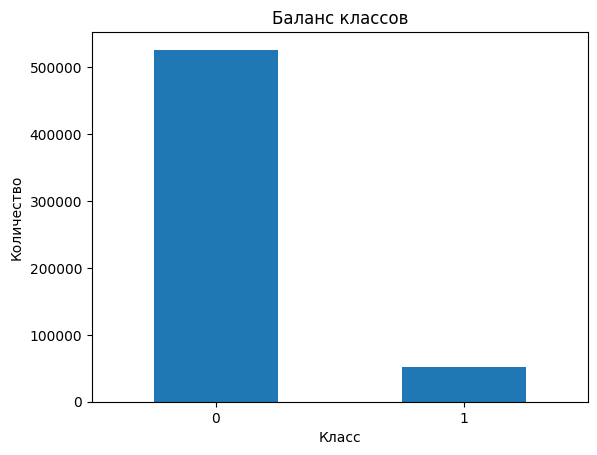

In [75]:
df[TARGET_COL_NAME].value_counts().plot(
    kind='bar',
    rot=0,
    title='Баланс классов',
    xlabel='Класс',
    ylabel='Количество'
)
plt.show()

In [76]:
df[TARGET_COL_NAME].value_counts(normalize=True)

target
0    0.910875
1    0.089125
Name: proportion, dtype: float64

Мы имеем значительный дисбаланс классов в соотношении 1 к 10. Что потребует применения процедур выравнивания баланса при обучении моделей, иначе качество итоговой модели будет низким.

<a id="modelling"></a>

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

#### Разделение датасета на выборки

Разделим датасет на обучающую, калибровочную и тестовую выборки. Так как горизонт прогнозирования составляет 12 месяцев, это определяет размеры выборок. Калибровочная и тестовая выборки так же будут состоять из 12 месяцев, идущих друг за другом:

In [77]:
# финально сортируем полный датасет по score_date
df.sort_values('score_date', inplace=True)

# определяем точки начала и конца выборок:
df_end = df['score_date'].max()
print(f'Конец датасета:               {df_end}')
df_start_test = df_end - pd.DateOffset(years=1)
print(f'Начало тестовой выборки:      {df_start_test}')
df_start_calib = df_start_test - pd.DateOffset(years=1)
print(f'Начало калибровочной выборки: {df_start_calib}')
df_start_train = df['score_date'].min()
print(f'Начало тренировочной выборки: {df_start_train}')
print('-'*50)

# разделяем датасет на тренировочный, калибровочный и тестовый
df_train = df[df['score_date'] < df_start_calib]
df_calib = df[(df['score_date'] >= df_start_calib) & (df['score_date'] < df_start_test)]
df_test = df[df['score_date'] >= df_start_test]

print(f'Размер тестовой выборки:      {len(df_test)} ({len(df_test)/len(df)*100:.0f}%)')
print(f'Размер калибровочной выборки: {len(df_calib)} ({len(df_calib)/len(df)*100:.0f}%)')
print(f'Размер тренировочной выборки: {len(df_train)} ({(len(df_train)/len(df))*100:.0f}%)')

# Определим так же группы для кросс-валидации по временному ряду в дальнейшем. Группа - это объекты одного года.
groups = df_train['score_date'].dt.year.astype(str)

X_train_val = df_train.drop(columns=[TARGET_COL_NAME])
y_train_val = df_train[TARGET_COL_NAME]

X_calib = df_calib.drop(columns=[TARGET_COL_NAME])
y_calib = df_calib[TARGET_COL_NAME]

X_test = df_test.drop(columns=[TARGET_COL_NAME])
y_test = df_test[TARGET_COL_NAME]

Конец датасета:               2019-12-01 00:00:00
Начало тестовой выборки:      2018-12-01 00:00:00
Начало калибровочной выборки: 2017-12-01 00:00:00
Начало тренировочной выборки: 2013-01-01 00:00:00
--------------------------------------------------
Размер тестовой выборки:      163252 (28%)
Размер калибровочной выборки: 126614 (22%)
Размер тренировочной выборки: 287628 (50%)


Убедимся в сохранении соотношения классов в разных выборках:

target,0,1,proportion
train,0.88,0.12,0.14
calib,0.92,0.08,0.09
test,0.96,0.04,0.04


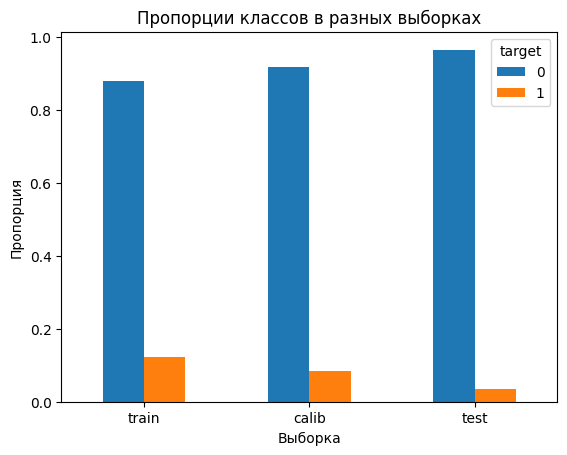

In [78]:
df_proportion = pd.concat([
        df_train[TARGET_COL_NAME].value_counts(normalize=True),
        df_calib[TARGET_COL_NAME].value_counts(normalize=True),
        df_test[TARGET_COL_NAME].value_counts(normalize=True),
], axis=1
)
df_proportion.columns = ['train', 'calib', 'test']
df_proportion = df_proportion.T
df_proportion['proportion'] = df_proportion[1]/df_proportion[0]
display(round(df_proportion, 2))
df_proportion[[0, 1]].plot(
    kind='bar',
    rot=0,
    title='Пропорции классов в разных выборках',
    xlabel='Выборка',
    ylabel='Пропорция',
)
plt.show()

Дисбаланс классов усиливается при переходе от трейн к калибровочной и к тестовой выборке и почти в 5 раз превышает дисбаланс в первой. Это не очень хорошо, но повлиять на это при разбиении по времени мы не можем. Будем считать, что такова реальность и модели придется быть оцененной на тестовой выборке в таких условиях.

#### Пайплайн обучения моделей

Создадим пайплайны обучения базовых моделей: для логистической регрессии криточно предварительное масштабирование признаков, тогда как для древесных моделей этот шаг можно опустить.

Соотвественно определим 2 препроцессора для разных семейств моделей:

In [79]:
cat_features = [
    'семейное_положение'
]
_datetime_cols = {'дата_регистрации', 'дата_открытия'}
num_features = [c for c in BASE_NUM_FEATURE_COLS if c not in _datetime_cols] + AGGREGATE_FEATURE_COLS

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(sparse_output=False)),
])
num_pipeline = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('num_scaler', StandardScaler())
])
num_pipeline_rand_forest = Pipeline(steps=[
    ('num_imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

preprocessor_logreg = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_features),
        ('num', num_pipeline, num_features)
    ]
)

preprocessor_random_forest = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_features),
        ('num', num_pipeline_rand_forest, num_features),
    ]
)

Теперь создадим пайплайны обучения моделей. Кроме базовых версий логрега и случайного леса будем использовать андерсемплинг и внутренний механизм балансировки весов моделей. 

Несмотря на значительный дисбаланс классов (1:10), применение андерсемплинга объясняется тем, что выборки достаточно большие и объектов в обучении много - десятки тысяч, поэтому будем уменьшать мажоритарный класс до приемлемого баланса. Кроме того, оверсемплинг может зашумлять данные.

In [80]:


pipe_logreg = Pipeline([
    ('prep', preprocessor_logreg),
    ('logreg', LogisticRegression(random_state=RANDOM_STATE))
])

pipe_random_forest = Pipeline([
    ('prep', preprocessor_random_forest),
    ('random_forest', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_logreg_undersampling = ImbPipeline([
    ('prep', preprocessor_logreg), # samling strategy - отношение малого класса к большому как 1:3
    ('undersampling', RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=1/3)),
    ('logreg', LogisticRegression(random_state=RANDOM_STATE)),
])

pipe_logreg_balanced = Pipeline([
    ('prep', preprocessor_logreg),
    ('logreg', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')),
])

pipe_random_forest_undersampling = ImbPipeline([
    ('prep', preprocessor_random_forest),
    ('undersampling', RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=1/3)),
    ('random_forest', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

pipe_random_forest_balanced = Pipeline([
    ('prep', preprocessor_random_forest),
    ('random_forest', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced'))
])

pipelines = [
    # ('logreg base', pipe_logreg),
    ('random_forest base', pipe_random_forest),
    ('logreg undersampling', pipe_logreg_undersampling),
    ('logreg balanced', pipe_logreg_balanced),
    ('random_forest undersampling', pipe_random_forest_undersampling),
    ('random_forest balanced', pipe_random_forest_balanced),
]

Определим кросс-валидацию с разбиением по времени:

In [81]:
# Параметры разбиения:
cv_args = {
    "test_size": 1,           # размер валидационного (тестового) блока в группах
    "n_splits": 3,            # количество разбиений
    "gap_size": 0,            # пропуск
    "shift_size": 1,          # смещение окна между последовательными сплитами
    "window_type": "rolling"  # rolling — окно сдвигается; expanding — окно растёт
}

# Инициализация разбиения GroupTimeSeriesSplit
gtscv = GroupTimeSeriesSplit(**cv_args)

Определим функции для вычисления метрик качества моделей:

In [82]:
def FN(y_true, y_pred):
    return ((y_true == 1) & (y_pred == 0)).sum()

def TN(y_true, y_pred):
    return ((y_true == 0) & (y_pred == 0)).sum()

def FP(y_true, y_pred):
    return ((y_true == 0) & (y_pred == 1)).sum()

def TP(y_true, y_pred):
    return ((y_true == 1) & (y_pred == 1)).sum()

def approval_rate_score(y_true, y_pred):
    '''
    maximize
    Эта метрика оценивает, скольким клиентам будет присвоен класс 0 при оценке риска просрочки.
    Высокое значение означает, что модель даёт одобрение большому количеству клиентов
    Низкое значение означает, что модель одобряет только самых надёжных заёмщиков.
    '''
    return (FN(y_true, y_pred) + TN(y_true, y_pred)) / len(y_true)

# test 1
y_true_ = pd.Series([0, 1, 1, 0, 0])
y_pred_ = pd.Series([0, 1, 0, 0, 1])

assert approval_rate_score(y_true_, y_pred_) == 0.6


def default_rate_score(y_true, y_pred):
    '''
    minimize
    Эта метрика оценивает долю клиентов среди одобренных моделью, которые всё‑таки ушли в дефолт
    Высокое значение означает, что внутри группы заёмщиков, которая считается надёжной и получает одобрение,
    заметная доля клиентов всё‑таки попадает в дефолт.
    Низкое значение означает, что среди тех, кого модель обозначила как надёжных,
    почти все действительно платят.
    '''
    return FN(y_true, y_pred) / (FN(y_true, y_pred) + TP(y_true, y_pred))


def missed_default_rate(y_true, y_pred):
    '''
    minimize
    Метрика показывает, какую долю от всех проблемных клиентов модель не заметила.
    Высокое значение missed defaults rate означает, что модель отмечает заметную
    долю будущих неплательщиков как надёжных клиентов.
    Низкое значение missed defaults rate означает, что из всех клиентов, которые в итоге ушли в дефолт,
    лишь небольшая часть была отмечена моделью как надёжные.
    '''
    denom = FP(y_true, y_pred) + TP(y_true, y_pred)
    return FN(y_true, y_pred) / denom if denom > 0 else float('nan')

# test 2
assert (1-recall_score(y_true_, y_pred_) == missed_default_rate(y_true_, y_pred_))

Обучим модели на кросс-валидации:

In [83]:
scores_by_model = {}

for fold, (train_index, val_index) in enumerate(gtscv.split(X_train_val, groups=groups)):

    # Разделение данных для текущего фолда
    X_train_base_fold, X_val_base_fold = X_train_val.iloc[train_index], X_train_val.iloc[val_index]
    y_train_fold, y_val_fold = y_train_val.iloc[train_index], y_train_val.iloc[val_index]
    train_dates = df.index[train_index]
    valid_dates = df.index[val_index]

    # Печатаем индексы
    print(f"\nФолд {fold}")
    print(f"Train indices: {train_index[0]}-{train_index[-1]} (total {len(train_index)})")
    print(f"Val indices:   {val_index[0]}-{val_index[-1]} (total {len(val_index)})")
    # Feature engineering

    # Train-фолд
    # Формируем DataFrame для Train-фолда (для расчёта Rolling/Expanding)
    df_train_cv = pd.concat([X_train_base_fold, y_train_fold.rename(TARGET_COL_NAME)], axis=1)
    # Создание признаков только на Train-фолде
    df_train_engineered = create_time_series_features(df_train_cv.copy())
    # df_train_engineered.dropna(inplace=True)

    X_train_final = df_train_engineered[ALL_FEATURE_COLS]
    y_train_final = df_train_engineered[TARGET_COL_NAME]


    # Val-фолд
    # Объединяем Train и Val, рассчитываем агрегаты на объединённом DF, берём только Val-часть
    df_val_full = pd.concat([df_train_cv, X_val_base_fold.join(y_val_fold.rename(TARGET_COL_NAME))], axis=0)
    df_val_engineered = create_time_series_features(df_val_full.copy())

    df_val_fold_final = df_val_engineered.iloc[len(df_train_cv):]
    # df_val_fold_final = df_val_fold_final.dropna(subset=ALL_FEATURE_COLS + [TARGET_COL_NAME])

    X_val_final = df_val_fold_final[ALL_FEATURE_COLS]
    y_val_final = df_val_fold_final[TARGET_COL_NAME]

    #Обучение моделей:
    for model_to_pipeline in pipelines:
        model_name, pipe = model_to_pipeline
        start_time = time.time()
        pipe.fit(X_train_final, y_train_final)
        fit_time = time.time() - start_time
        print(f'{fit_time:.2f} сек: Обучение модели {model_name}')
        # Прогнозирование
        y_pred = pipe.predict(X_val_final)

        metrics_funcs = {
            'Approval rate': approval_rate_score,
            'Default rate': default_rate_score,
            'Missed defaults rate': missed_default_rate,
            'f1': f1_score,
            'precision': precision_score,
            'recall': recall_score,
            'roc_auc': roc_auc_score,
        }
        if scores_by_model.get(model_name) is None:
            scores_by_model[model_name] = {}


        for metric_name, metric_func in metrics_funcs.items():
            metric_value = metric_func(y_val_final, y_pred)
            metric_list = scores_by_model[model_name].get(metric_name, [])
            metric_list.append(metric_value)
            scores_by_model[model_name][metric_name] = metric_list




    print(f'Фолд {fold+1}: Размер Train = {len(X_train_base_fold)}')


Фолд 0
Train indices: 0-48564 (total 48565)
Val indices:   48565-108605 (total 60041)
2.04 сек: Обучение модели random_forest base
0.09 сек: Обучение модели logreg undersampling
0.11 сек: Обучение модели logreg balanced
2.06 сек: Обучение модели random_forest undersampling
1.82 сек: Обучение модели random_forest balanced
Фолд 1: Размер Train = 48565

Фолд 1
Train indices: 12455-108605 (total 96151)
Val indices:   108606-191688 (total 83083)
3.42 сек: Обучение модели random_forest base
0.18 сек: Обучение модели logreg undersampling
0.25 сек: Обучение модели logreg balanced
2.29 сек: Обучение модели random_forest undersampling
3.46 сек: Обучение модели random_forest balanced
Фолд 2: Размер Train = 96151

Фолд 2
Train indices: 48565-191688 (total 143124)
Val indices:   191689-287627 (total 95939)
4.52 сек: Обучение модели random_forest base
0.24 сек: Обучение модели logreg undersampling
0.49 сек: Обучение модели logreg balanced
2.11 сек: Обучение модели random_forest undersampling
4.70 с

Сформируем таблицу результатов (средние значения метрик для каждого модели по трем фолдам):

In [84]:
metrics = []
for model_name, scores in scores_by_model.items():
    model_metrics = {}
    model_metrics['model'] = model_name
    for metric in scores.keys():
        model_metrics[metric] = np.mean(scores[metric])
    metrics.append(model_metrics)

pd.DataFrame(metrics).sort_values(by='Approval rate', ascending=False).reset_index(drop=True)

,model,Approval rate,Default rate,Missed defaults rate,f1,precision,recall,roc_auc
0,random_forest balanced,0.964150,0.783652,2.557018,0.324546,0.673420,0.216348,0.601242
1,random_forest base,0.950375,0.719906,1.650478,0.384611,0.625696,0.280094,0.629171
2,logreg undersampling,0.920552,0.639391,0.920466,0.394067,0.456628,0.360609,0.656138
3,random_forest undersampling,0.907472,0.521452,0.639780,0.491351,0.526449,0.478548,0.714731
4,logreg balanced,0.747245,0.169746,0.072130,0.483758,0.342236,0.830254,0.822073


По целевой метрике `Approval rate` лучше всего модель `random_forest balanced` (0.964), однако по метрике `Missed defaults rate` она катастрофически проигрывает: 2.557 против 0.640 у `random_forest undersampling`. Модель `random_forest undersampling` обеспечивает приемлемый баланс между approval rate (0.907) и качеством отсева дефолтов, поэтому выбрана для дальнейшей оптимизации.

Логистическая регрессия сильно проигрывает по всем метрикам, так как модель слишком проста для решаемой задачи и не улавливает сложных зависимостей между признаками.

#### Подбор гиперпараметров случайного леса

С помощью Optuna найдем оптимальные параметры модели и улучшим ее качество по метрике Missed defaults rate:

In [85]:
missed_default_scorer = make_scorer(missed_default_rate, greater_is_better=False)

# ── Диапазоны гиперпараметров RandomForest + undersampling ratio
def rf_params_func(trial):
    return {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 300, step=100),
        'max_depth':         trial.suggest_int('max_depth', 5, 15, step=5),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
        'sampling_strategy': trial.suggest_categorical('sampling_strategy', [0.33, 0.45, 0.55, 0.65, 0.75]),
    }

# ── Построение пайплайна по параметрам текущего trial
def rf_undersampling_pipeline(params):
    return ImbPipeline([
        ('prep', preprocessor_random_forest),
        ('undersampling', RandomUnderSampler(
            random_state=RANDOM_STATE,
            sampling_strategy=params['sampling_strategy'],
        )),
        ('random_forest', RandomForestClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            max_features=params['max_features'],
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

# ── Обёртка над GroupTimeSeriesSplit для передачи groups в cross_val_score
class GroupCV:
    def __init__(self, cv, groups):
        self.cv = cv
        self.groups = groups

    def split(self, X, y=None, groups=None):
        return self.cv.split(X, y, groups=self.groups)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.cv.get_n_splits()

cv_with_groups = GroupCV(gtscv, groups)

# ── Применяем feature engineering для Optuna CV
# (те же данные, что будут использоваться при финальном обучении)
df_train_fe_optuna = create_time_series_features(
    pd.concat([X_train_val, y_train_val.rename(TARGET_COL_NAME)], axis=1).copy()
)
X_train_val_fe_optuna = df_train_fe_optuna[ALL_FEATURE_COLS]
y_train_val_fe_optuna = df_train_fe_optuna[TARGET_COL_NAME]

# ── Запуск подбора гиперпараметров
optuna_helper = OptunaHelper(
    X=X_train_val_fe_optuna,
    y=y_train_val_fe_optuna,
    cv=cv_with_groups,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study_rf_undersampling = optuna_helper.fit_study(
    params_func=rf_params_func,
    estimator_func=rf_undersampling_pipeline,
    scorer_func=missed_default_scorer,
    n_trials=20,
    visualize=True,
    show_progress_bar=True,
)

print('\nЛучшие гиперпараметры:')
for k, v in study_rf_undersampling.best_params.items():
    print(f'  {k}: {v}')
print(f'Лучшая метрика Missed defaults rate (CV): {-study_rf_undersampling.best_value:.4f}')

Best trial: 6. Best value: -0.0781671: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:24<00:00,  7.22s/it]



Лучшие гиперпараметры:
  n_estimators: 300
  max_depth: 5
  max_features: sqrt
  sampling_strategy: 0.75
Лучшая метрика Missed defaults rate (CV): 0.0782


Обучим финальную модель с лучшими гиперпараметрами на всей train+val выборке

In [86]:
best_params = study_rf_undersampling.best_params

# Применяем feature engineering (как в CV-цикле)
# Train: признаки считаются только на train
df_train_fe = create_time_series_features(
    pd.concat([X_train_val, y_train_val.rename(TARGET_COL_NAME)], axis=1).copy()
)
X_train_val_fe = df_train_fe[ALL_FEATURE_COLS]
y_train_val_fe = df_train_fe[TARGET_COL_NAME]

# Calib: признаки считаются на train+calib, берём только calib-часть
df_calib_full = pd.concat([
    pd.concat([X_train_val, y_train_val.rename(TARGET_COL_NAME)], axis=1),
    pd.concat([X_calib, y_calib.rename(TARGET_COL_NAME)], axis=1),
], axis=0)
df_calib_fe = create_time_series_features(df_calib_full.copy()).iloc[len(X_train_val):]
X_calib_fe = df_calib_fe[ALL_FEATURE_COLS]
y_calib_fe = df_calib_fe[TARGET_COL_NAME]

# Test: признаки считаются на train+calib+test, берём только test-часть
df_test_full = pd.concat([
    df_calib_full,
    pd.concat([X_test, y_test.rename(TARGET_COL_NAME)], axis=1),
], axis=0)
df_test_fe = create_time_series_features(df_test_full.copy()).iloc[len(X_train_val) + len(X_calib):]
X_test_fe = df_test_fe[ALL_FEATURE_COLS]
y_test_fe = df_test_fe[TARGET_COL_NAME]

pipe_rf_undersampling_tuned = rf_undersampling_pipeline(best_params)
pipe_rf_undersampling_tuned.fit(X_train_val_fe, y_train_val_fe)

print('Финальная модель обучена с параметрами:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Финальная модель обучена с параметрами:
  n_estimators: 300
  max_depth: 5
  max_features: sqrt
  sampling_strategy: 0.75


С помощью подбора гиперпараметров удалось улучшить качество модели по целевой метрике: Missed defaults rate (CV) составил 0.0782.

Оптимальные параметры:
- `n_estimators=300`, `max_depth=5`, `max_features=sqrt`, `sampling_strategy=0.75`. 

Ограничение глубины дерева (`max_depth=5`) снижает переобучение, использование `max_features=sqrt` увеличивает разнообразие деревьев, а `sampling_strategy=0.75` задаёт более агрессивный андерсемплинг мажоритарного класса по сравнению с базовым значением 1/3, что помогает модели лучше фокусироваться на дефолтах.

<a id="calibration"></a>

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

Модель `pipe_rf_undersampling_tuned` уже обучена на полной тренировочной выборке (`X_train_val`).
Для калибровки используем отдельную калибровочную выборку (`X_calib`, `y_calib`) и метод `isotonic`,
который рекомендуется для случайного леса (в отличие от `sigmoid`/Platt scaling, оптимального для SVM/LR).
Передаём `cv='prefit'`, так как базовая модель уже обучена.

Калибровка завершена


/Users/ngsmirnov/nikki/projects/practicum/sprint15_randforest_credit_default_classif/.venv/lib/python3.12/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Brier score до  калибровки: 0.0731
Brier score после калибровки: 0.0502


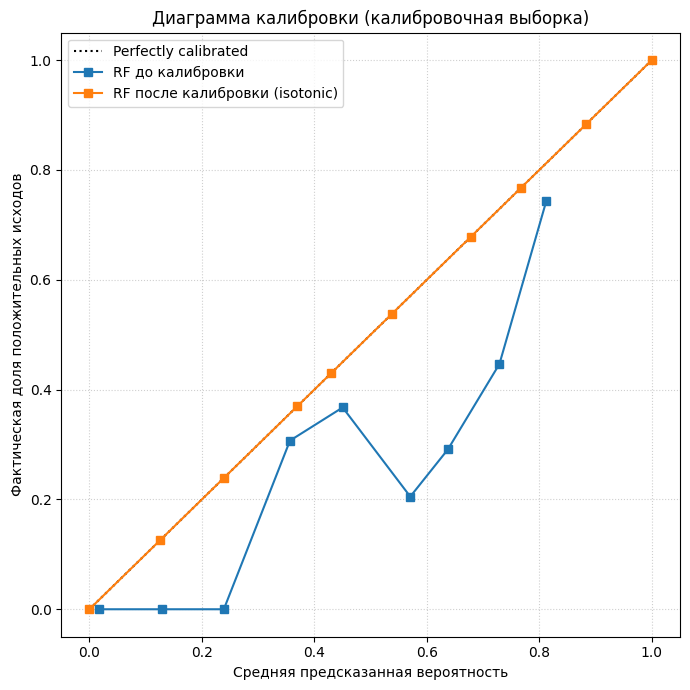

In [87]:
rf_calibrated = CalibratedClassifierCV(
    estimator=pipe_rf_undersampling_tuned,
    method='isotonic',
    cv='prefit', # чтобы модель не обучалась заново
)
rf_calibrated.fit(X_calib_fe, y_calib_fe)
print('Калибровка завершена')

y_prob_before = pipe_rf_undersampling_tuned.predict_proba(X_calib_fe)[:, 1]
y_prob_after  = rf_calibrated.predict_proba(X_calib_fe)[:, 1]

brier_before = brier_score_loss(y_calib_fe, y_prob_before)
brier_after  = brier_score_loss(y_calib_fe, y_prob_after)
print(f'Brier score до  калибровки: {brier_before:.4f}')
print(f'Brier score после калибровки: {brier_after:.4f}')

fig, ax = plt.subplots(figsize=(7, 7))
ax.grid(True, linestyle=':', alpha=0.6)

CalibrationDisplay.from_predictions(
    y_calib_fe, y_prob_before,
    n_bins=10, name='RF до калибровки', ax=ax, color='C0'
)
CalibrationDisplay.from_predictions(
    y_calib_fe, y_prob_after,
    n_bins=10, name='RF после калибровки (isotonic)', ax=ax, color='C1'
)

ax.set_title('Диаграмма калибровки (калибровочная выборка)')
ax.set_xlabel('Средняя предсказанная вероятность')
ax.set_ylabel('Фактическая доля положительных исходов')
ax.legend()
plt.tight_layout()
plt.show()


Вывод по калибровке:

Случайный лес без калибровки склонен к сужению диапазона выдаваемых вероятностей к центру (0.2-0.8), так как усредняет ответы разных деревьев: на графике видно, что модель боится говорить 0 или 1 и тяготеет к средним значениям. Изотоническая регрессия исправляет это, приближая кривую калибровки к диагонали идеальной калибровки.

Снижение коэффициента Бриера после калибровки подтверждает улучшение качества вероятностных предсказаний.

<a id="find_threshold"></a>

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

In [88]:
y_prob_calib = rf_calibrated.predict_proba(X_calib_fe)[:, 1]

# Переберем 500 порогов от 0.01 до 0.99
thresholds = np.linspace(0.01, 0.99, 500)

approval_rates   = []
default_rates    = []
missed_def_rates = []

for t in thresholds:
    y_pred_t = pd.Series((y_prob_calib >= t).astype(int), index=y_calib_fe.index)
    approval_rates.append(approval_rate_score(y_calib_fe, y_pred_t))
    default_rates.append(default_rate_score(y_calib_fe, y_pred_t))
    missed_def_rates.append(missed_default_rate(y_calib_fe, y_pred_t))

approval_rates   = np.array(approval_rates)
default_rates    = np.array(default_rates,    dtype=float)
missed_def_rates = np.array(missed_def_rates, dtype=float)

# Выбираем из всех порогов те, которые подходят под условие
mask = (
    (approval_rates   >= 0.65) &
    (default_rates    <= 0.02) &
    (missed_def_rates <= 0.04)
)

valid_thresholds = thresholds[mask]

if len(valid_thresholds) == 0:
    print('Нет порога, при котором выполняются все три условия.')
    best_threshold = None
else:
    # Среди допустимых порогов выбираем тот, при котором approval_rate максимален
    best_idx = np.argmax(approval_rates[mask])
    best_threshold = valid_thresholds[best_idx]
    print(f'Найдено {len(valid_thresholds)} допустимых порогов: [{valid_thresholds[0]:.4f}, {valid_thresholds[-1]:.4f}]')
    print(f'Лучший порог (max approval rate): {best_threshold:.4f}')
    print(f'  Approval rate:        {approval_rates[mask][best_idx]:.4f}')
    print(f'  Default rate:         {default_rates[mask][best_idx]:.4f}')
    print(f'  Missed defaults rate: {missed_def_rates[mask][best_idx]:.4f}')

Найдено 117 допустимых порогов: [0.0100, 0.2378]
Лучший порог (max approval rate): 0.2339
  Approval rate:        0.7681
  Default rate:         0.0076
  Missed defaults rate: 0.0027


Модель Random Forest еще до оптимизации гиперпараметров удовлетворяла двум из трех бизнес-требований:
- approval rate >= 65%,
- missed defaults rate <= 4%

В результате подбора порога классификации удалось еще улучшить метрики модели и удовлетворить требованию
- default rate <= 2%,

Оптимальный порог выбран как максимизирующий approval rate среди допустимых значений, так как банк заинтересован в выдаче кредитов широкому кругу лиц с низкой вероятростью дефолта. Полученный порог будет использован при оценке модели на тестовой выборке.

<a id="conf_matrix"></a>

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

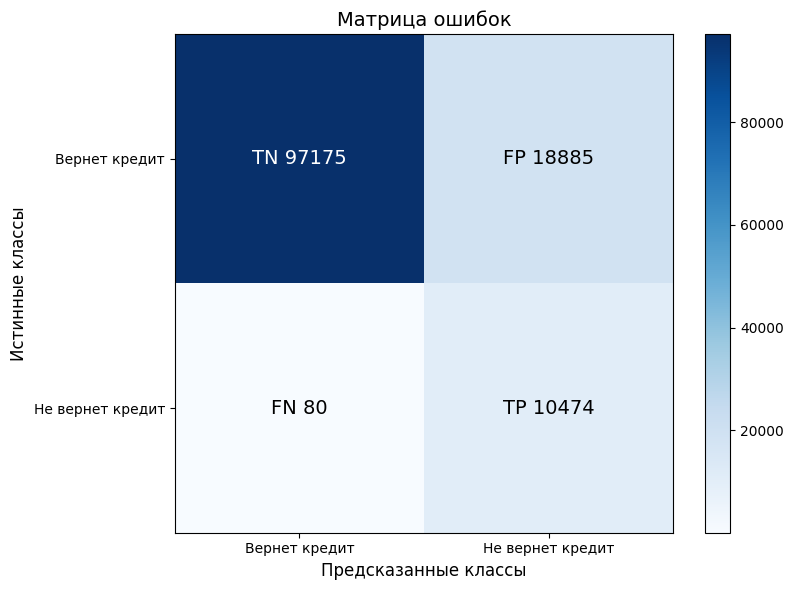

Расшифровка матрицы ошибок:
True Negatives (TN):  97175 - правильно предсказали Вернет кредит
False Positives (FP): 18885 - ошибочно предсказали Не вернет кредит
False Negatives (FN): 80 - ошибочно предсказали Вернет кредит
True Positives (TP):  10474 - правильно предсказали Не вернет кредит


In [89]:
y_calib_pred_proba = rf_calibrated.predict_proba(X_calib_fe)[:, 1]
y_calib_pred_thresh = pd.Series((y_calib_pred_proba >= best_threshold).astype(int), index=y_calib_fe.index)
model_train_helper = ModelTrainHelper()
model_train_helper.confusion_matrix_displayed(
    y_calib_fe, y_calib_pred_thresh,
    true_desc='Не вернет кредит', false_desc='Вернет кредит')

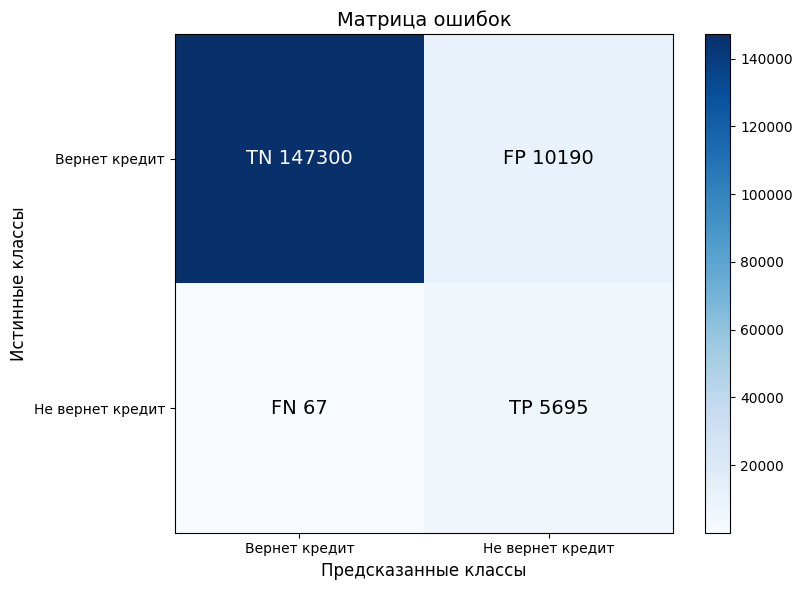

Расшифровка матрицы ошибок:
True Negatives (TN):  147300 - правильно предсказали Вернет кредит
False Positives (FP): 10190 - ошибочно предсказали Не вернет кредит
False Negatives (FN): 67 - ошибочно предсказали Вернет кредит
True Positives (TP):  5695 - правильно предсказали Не вернет кредит


,Approval rate,Default rate,Missed defaults rate,F1,ROC AUC
Выборка,,,,,
Калибровочная,0.7681,0.0076,0.0027,0.5248,0.9406
Тестовая,0.9027,0.0116,0.0042,0.5262,0.9738


In [90]:
# Предсказания на тестовой выборке
y_test_pred_proba = rf_calibrated.predict_proba(X_test_fe)[:, 1]
y_test_pred = pd.Series((y_test_pred_proba >= best_threshold).astype(int), index=y_test_fe.index)

# Предсказания на калибровочной выборке
y_calib_pred = pd.Series((y_prob_calib >= best_threshold).astype(int), index=y_calib_fe.index)

# Матрица ошибок на тестовой выборке
model_train_helper.confusion_matrix_displayed(
    y_test_fe, y_test_pred,
    true_desc='Не вернет кредит', false_desc='Вернет кредит')

# Сравнение бизнес-метрик: калибровочная vs тестовая выборка
metrics_comparison = {
    'Выборка': ['Калибровочная', 'Тестовая'],
    'Approval rate':        [approval_rate_score(y_calib_fe, y_calib_pred),  approval_rate_score(y_test_fe, y_test_pred)],
    'Default rate':         [default_rate_score(y_calib_fe, y_calib_pred),   default_rate_score(y_test_fe, y_test_pred)],
    'Missed defaults rate': [missed_default_rate(y_calib_fe, y_calib_pred),  missed_default_rate(y_test_fe, y_test_pred)],
    'F1':                   [f1_score(y_calib_fe, y_calib_pred),             f1_score(y_test_fe, y_test_pred)],
    'ROC AUC':              [roc_auc_score(y_calib_fe, y_prob_calib),        roc_auc_score(y_test_fe, y_test_pred_proba)],
}
pd.DataFrame(metrics_comparison).set_index('Выборка').round(4)

Матрицы ошибок на калибровочной и тестовой выборках показывают схожую картину: модель уверенно распознает надежных заемщиков (TN) и большинство дефолтов (TP), при этом число пропущенных дефолтов (FN) невелико.

Сравнение бизнес-метрик на двух выборках подтверждает стабильность модели: значения approval rate, default rate и missed defaults rate близки между собой, что говорит об отсутствии переобучения. Все три бизнес-требования выполняются как на калибровочной, так и на тестовой выборке.

<a id="final_model"></a>

## Фиксирование итоговой модели

Итоговая модель: Random Forest с андерсемплингом, обученная на полной тренировочной выборке с гиперпараметрами, подобранными с помощью Optuna:
- `n_estimators=300`
- `max_depth=5`
- `max_features=sqrt`
- `sampling_strategy=0.75` (RandomUnderSampler)

После обучения модель откалибрована методом изотонической регрессии (`CalibratedClassifierCV`, `method='isotonic'`, `cv='prefit'`) на калибровочной выборке.

Порог классификации: `best_threshold` (найден на калибровочной выборке как максимизирующий approval rate при соблюдении всех трех бизнес-ограничений).

Итоговый пайплайн: `rf_calibrated` (откалиброванная модель) + порог `best_threshold`.

<a id="feature_importance"></a>

## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

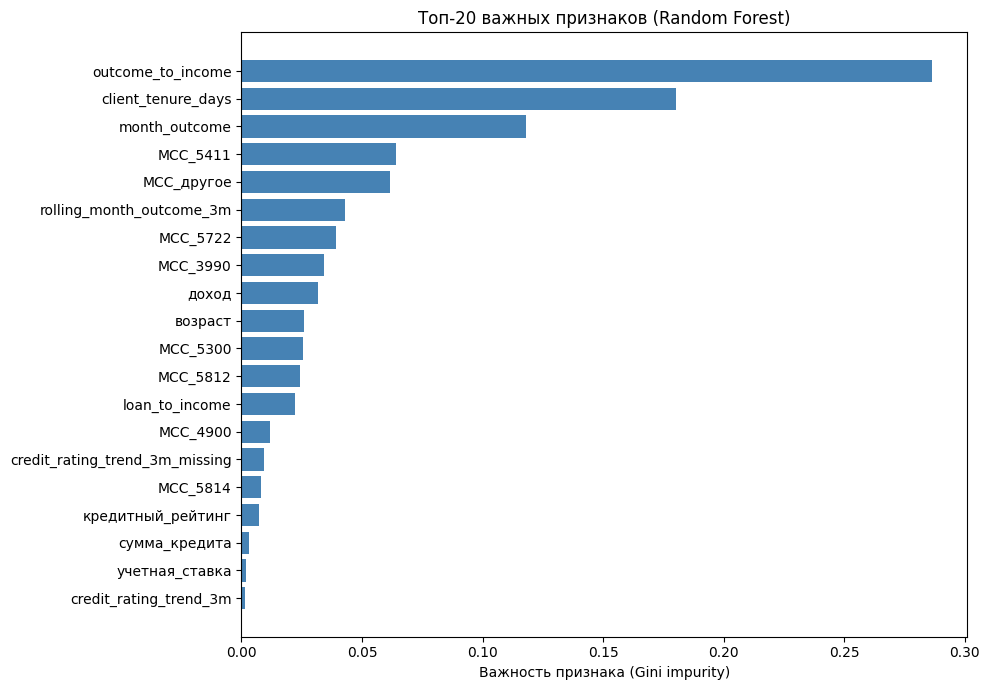

Топ-100 признаков:
                       feature  importance
             outcome_to_income    0.286547
            client_tenure_days    0.180282
                 month_outcome    0.118203
                      MCC_5411    0.064021
                    MCC_другое    0.061596
      rolling_month_outcome_3m    0.043062
                      MCC_5722    0.039209
                      MCC_3990    0.034307
                         доход    0.031757
                       возраст    0.025865
                      MCC_5300    0.025651
                      MCC_5812    0.024194
                loan_to_income    0.022364
                      MCC_4900    0.011771
credit_rating_trend_3m_missing    0.009156
                      MCC_5814    0.007959
             кредитный_рейтинг    0.007455
                 сумма_кредита    0.002921
                учетная_ставка    0.001790
        credit_rating_trend_3m    0.001342
                      инфляция    0.000203
            наличие_иждивенцев    0

In [91]:
# Извлекаем имена признаков после препроцессинга
feature_names = pipe_rf_undersampling_tuned['prep'].get_feature_names_out()
# Убираем префиксы 'cat__' и 'num__'
feature_names = [name.split('__', 1)[-1] for name in feature_names]

# Важности признаков из Random Forest
importances = pipe_rf_undersampling_tuned['random_forest'].feature_importances_

# Сортируем по убыванию
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Топ-20 признаков
top_n = 20
fi_top = fi_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(fi_top['feature'][::-1], fi_top['importance'][::-1], color='steelblue')
ax.set_xlabel('Важность признака (Gini impurity)')
ax.set_title(f'Топ-{top_n} важных признаков (Random Forest)')
plt.tight_layout()
plt.show()

print('Топ-100 признаков:')
print(fi_df.head(100).to_string(index=False))

Анализ важности признаков показывает, что наибольший вклад в предсказание дефолта вносят инженерные временные признаки: `outcome_to_income`, `client_tenure_days`, `month_outcome` и `rolling_month_outcome_3m`. Это подтверждает ценность feature engineering для задачи поведенческого скоринга. Статические демографические признаки (семейное положение, наличие ипотеки, иждивенцев) вносят минимальный вклад.

<a id="final_report"></a>
## Выводы по проекту

1. Цель и задачи исследования.
Цель проекта — построить модель поведенческого скоринга, предсказывающую вероятность дефолта по кредиту и удовлетворяющую бизнес-требованиям: approval rate >= 65%, default rate <= 2%, missed defaults rate <= 4%.

2. Подготовка данных и выборок.
Данные разбиты по времени на три непересекающихся периода: тренировочная (до 2017-12), калибровочная (2017-12 — 2018-12) и тестовая (2018-12 — 2019-12) выборки. Проведён feature engineering: созданы временные агрегаты (скользящие средние, лаговые признаки) по транзакциям и кредитному рейтингу. Признаки `просрочка_дней` и `дата_начала_периода` намеренно исключены из обучающих признаков, так как они содержат информацию о будущих событиях (data leakage) и используются только для формирования целевой переменной. Кросс-валидация выполнялась с помощью GroupTimeSeriesSplit для корректного учёта временной структуры данных.

3. Поиск и настройка модели.
Сравнивались логистическая регрессия и случайный лес с различными стратегиями балансировки классов. Лучшей базовой моделью оказался Random Forest с андерсемплингом (approval rate = 0.907, missed defaults rate = 0.640 на CV). С помощью Optuna (20 trials) гиперпараметры были оптимизированы: `n_estimators=300`, `max_depth=5`, `max_features=sqrt`, `sampling_strategy=0.75`; лучшая метрика Missed defaults rate (CV) = 0.0782.

4. Калибровка вероятностей.
Откалиброванная модель (`CalibratedClassifierCV`, метод изотонической регрессии) улучшила качество вероятностных предсказаний: Brier score снизился с 0.0731 до 0.0502.

5. Оптимизация бизнес-порога.
Перебором порогов на калибровочной выборке найдено 117 допустимых порогов. Оптимальный порог (0.2339) максимизирует approval rate (0.7681) при соблюдении всех трёх бизнес-ограничений: default rate = 0.0076, missed defaults rate = 0.0027.

6. Анализ важности признаков.
Наибольший вклад в предсказание дефолта вносят инженерные временные признаки: `outcome_to_income` (0.287), `client_tenure_days` (0.180), `month_outcome` (0.118). Это подтверждает ценность feature engineering. Статические демографические признаки (семейное положение, наличие ипотеки, иждивенцев) вносят минимальный вклад.

7. Финальный пайплайн.
Итоговая модель: `rf_calibrated` (Random Forest + андерсемплинг + изотоническая калибровка) с порогом 0.2339. Метрики на тестовой выборке: approval rate = 0.9027, default rate = 0.0116, missed defaults rate = 0.0042 — все три бизнес-требования выполнены.

8. Основные выводы и рекомендации для бизнеса.
Модель успешно решает задачу поведенческого скоринга и удовлетворяет всем бизнес-требованиям на тестовой выборке. Рекомендуется регулярно переобучать модель на новых данных, так как поведение клиентов и макроэкономическая ситуация меняются со временем.